# 강원도 산불 로지스틱 모델링

이 노트북은 로지스틱 모델링 계획의 **1~4단계**를 재현 가능하게 고정한다.

1. 캐나다 산불지수의 같은 날 12시 시간 누수를 제거하고 D-1 정오 지수로 재병합
2. Target 1과 Target 0-A를 묶는 그룹 ID 복원
3. M1/M2/M3 변수 목록 확정과 모델링 데이터 저장
4. group lockbox, outer 5-fold, inner 4-fold 분할 manifest 저장

아직 모델 학습은 수행하지 않는다. 5단계부터 Dummy와 L2 로지스틱을 동일한 분할에서 학습한다.

## 0. 환경 설정

- 프로젝트 루트를 자동 탐색한다.
- 모든 CSV는 `utf-8-sig`로 읽고 쓴다.
- 모델링용 데이터는 `data/학습데이터`에 저장한다.
- 변수 manifest와 split manifest는 `jsw/Analysis/logistic/outputs`에 저장한다.

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.model_selection import StratifiedGroupKFold

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

RANDOM_STATE = 20260618


def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    candidates = [start, *start.parents]
    for candidate in candidates:
        target = candidate / "data" / "학습데이터" / "학습데이터_최종_캐나다지수.csv"
        if target.exists():
            return candidate
    raise FileNotFoundError("프로젝트 루트를 찾지 못했습니다.")


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data" / "학습데이터"
ANALYSIS_DIR = PROJECT_ROOT / "jsw" / "Analysis" / "logistic"
OUTPUT_DIR = ANALYSIS_DIR / "outputs"
MANIFEST_DIR = OUTPUT_DIR / "manifests"
SPLIT_DIR = OUTPUT_DIR / "splits"

for directory in [OUTPUT_DIR, MANIFEST_DIR, SPLIT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

FINAL_CANADA_PATH = DATA_DIR / "학습데이터_최종_캐나다지수.csv"
MERGED_META_PATH = DATA_DIR / "학습데이터_병합.csv"
FFMC_DAILY_PATH = DATA_DIR / "캐나다_FFMC_선행연구_일단위.csv"
FWI_DAILY_PATH = DATA_DIR / "캐나다_FWI_일단위.csv"
MODELING_DATA_PATH = DATA_DIR / "학습데이터_로지스틱_D1.csv"
FEATURE_MANIFEST_PATH = MANIFEST_DIR / "feature_manifest.json"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("Python 준비 완료")

PROJECT_ROOT: D:\farm-system-public-02
Python 준비 완료


## 1단계. 캐나다 지수 시간 누수 수정

현재 확장본의 캐나다 지수는 같은 날 12시 기상값을 날짜 기준으로 병합했다. 12시 이전 행에서는 미래 정보가 되므로 기존 캐나다 지수 컬럼을 제거하고, 각 기준시각 날짜의 **D-1 정오 지수**를 다시 붙인다.

주 분석 정책:

- 모든 시간대에 D-1 정오 지수 사용
- 병합 지수 날짜가 기준 날짜보다 정확히 1일 이전인지 검증
- 기존 행 수, `샘플ID`, Target 분포 보존

In [2]:
base = pd.read_csv(
    FINAL_CANADA_PATH,
    encoding="utf-8-sig",
    parse_dates=["기준시각"],
)
ffmc_daily = pd.read_csv(
    FFMC_DAILY_PATH,
    encoding="utf-8-sig",
    parse_dates=["날짜"],
)
fwi_daily = pd.read_csv(
    FWI_DAILY_PATH,
    encoding="utf-8-sig",
    parse_dates=["날짜"],
)

canadian_original_cols = [
    "FFMC",
    "FFMC_10일평균",
    "Indexed_FFMC",
    "FFMC_논문식_발생확률",
    "DMC",
    "DC",
    "ISI",
    "BUI",
    "FWI",
]

missing_original = [c for c in canadian_original_cols if c not in base.columns]
assert not missing_original, f"기존 캐나다 지수 컬럼 누락: {missing_original}"
assert not ffmc_daily.duplicated(["기상셀ID", "날짜"]).any()
assert not fwi_daily.duplicated(["기상셀ID", "날짜"]).any()

ffmc_match = ffmc_daily[["기상셀ID", "날짜", "FFMC"]].merge(
    fwi_daily[["기상셀ID", "날짜", "FFMC"]],
    on=["기상셀ID", "날짜"],
    suffixes=("_선행연구", "_FWI"),
    validate="one_to_one",
)
max_ffmc_diff = (
    ffmc_match["FFMC_선행연구"] - ffmc_match["FFMC_FWI"]
).abs().max()
assert max_ffmc_diff < 1e-10

daily = ffmc_daily[
    [
        "기상셀ID",
        "날짜",
        "FFMC",
        "FFMC_10일평균",
        "Indexed_FFMC",
        "FFMC_논문식_발생확률",
    ]
].merge(
    fwi_daily[["기상셀ID", "날짜", "DMC", "DC", "ISI", "BUI", "FWI"]],
    on=["기상셀ID", "날짜"],
    how="inner",
    validate="one_to_one",
)

daily = daily.rename(
    columns={
        "FFMC": "D1_FFMC",
        "FFMC_10일평균": "D1_FFMC_10일평균",
        "Indexed_FFMC": "D1_Indexed_FFMC",
        "FFMC_논문식_발생확률": "D1_FFMC_논문식_발생확률",
        "DMC": "D1_DMC",
        "DC": "D1_DC",
        "ISI": "D1_ISI",
        "BUI": "D1_BUI",
        "FWI": "D1_FWI",
    }
)
daily["D1_지수기준날짜"] = daily["날짜"]
daily["병합대상날짜"] = daily["날짜"] + pd.Timedelta(days=1)
daily = daily.drop(columns="날짜")

unsafe_before_noon = int((base["기준시각"].dt.hour < 12).sum())
unsafe_before_noon_positive = int(
    ((base["기준시각"].dt.hour < 12) & base["Target"].eq(1)).sum()
)

base_without_canada = base.drop(columns=canadian_original_cols)
base_without_canada["기준날짜"] = base_without_canada["기준시각"].dt.normalize()

data = base_without_canada.merge(
    daily,
    left_on=["기상셀ID", "기준날짜"],
    right_on=["기상셀ID", "병합대상날짜"],
    how="left",
    validate="many_to_one",
)
data = data.drop(columns="병합대상날짜")
data["캐나다지수_정책"] = "D-1 정오"

d1_cols = [c for c in data.columns if c.startswith("D1_") and c != "D1_지수기준날짜"]

assert len(data) == len(base)
assert data["샘플ID"].is_unique
assert data["샘플ID"].tolist() == base["샘플ID"].tolist()
assert data["Target"].value_counts().to_dict() == base["Target"].value_counts().to_dict()
assert data[d1_cols].isna().sum().sum() == 0
assert (data["기준날짜"] - data["D1_지수기준날짜"]).eq(pd.Timedelta(days=1)).all()

step1_summary = pd.DataFrame(
    {
        "검증항목": [
            "행 수",
            "Target 1",
            "Target 0",
            "12:00 이전 전체 행",
            "12:00 이전 Target 1",
            "D-1 지수 결측",
            "FFMC 두 산출물 최대차",
        ],
        "결과": [
            len(data),
            int(data["Target"].sum()),
            int(data["Target"].eq(0).sum()),
            unsafe_before_noon,
            unsafe_before_noon_positive,
            int(data[d1_cols].isna().sum().sum()),
            float(max_ffmc_diff),
        ],
    }
)
display(step1_summary)

,검증항목,결과
0,행 수,17045.0
1,Target 1,1553.0
2,Target 0,15492.0
3,12:00 이전 전체 행,7777.0
4,12:00 이전 Target 1,693.0
5,D-1 지수 결측,0.0
6,FFMC 두 산출물 최대차,0.0


## 2단계. 그룹 ID 복원

무작위 행 분할을 금지한다. 동일 산불에서 파생된 Target 1과 0-A는 하나의 그룹으로 묶고, 공간 대조군 0-B1/0-B2는 후보점별 독립 그룹으로 둔다.

- Target 1/0-A: `source_fire_id`
- Target 0-B1/0-B2: `후보점ID`
- 최종 `모델링_그룹ID`는 이후 모든 split의 기준이다.

In [3]:
meta_cols = ["샘플ID", "fire_id", "원본_fire_id", "후보점ID"]
meta = pd.read_csv(
    MERGED_META_PATH,
    encoding="utf-8-sig",
    usecols=meta_cols,
    dtype="string",
)

assert meta["샘플ID"].is_unique
data = data.merge(meta, on="샘플ID", how="left", validate="one_to_one")

data["source_fire_id"] = data["원본_fire_id"].fillna(data["fire_id"])
fire_mask = data["샘플유형"].isin(["Target_1", "Target_0A"])
background_mask = data["샘플유형"].isin(["Target_0B1", "Target_0B2"])

assert data.loc[fire_mask, "source_fire_id"].notna().all()
assert data.loc[background_mask, "후보점ID"].notna().all()

data["모델링_그룹ID"] = pd.Series(pd.NA, index=data.index, dtype="string")
data.loc[fire_mask, "모델링_그룹ID"] = (
    "FIRE_" + data.loc[fire_mask, "source_fire_id"].astype("string")
)
data.loc[background_mask, "모델링_그룹ID"] = (
    "BG_" + data.loc[background_mask, "후보점ID"].astype("string")
)

assert data["모델링_그룹ID"].notna().all()

fire_group_check = (
    data.loc[fire_mask]
    .groupby("모델링_그룹ID", observed=True)
    .agg(
        행수=("샘플ID", "size"),
        양성수=("Target", "sum"),
        Target1수=("샘플유형", lambda s: int((s == "Target_1").sum())),
        Target0A수=("샘플유형", lambda s: int((s == "Target_0A").sum())),
    )
)

assert fire_group_check["양성수"].eq(1).all()
assert fire_group_check["Target1수"].eq(1).all()
assert not data.loc[background_mask, "모델링_그룹ID"].duplicated().any()

step2_summary = pd.DataFrame(
    {
        "항목": [
            "전체 그룹 수",
            "산불 source 그룹 수",
            "공간 배경 그룹 수",
            "그룹 ID 결측",
            "산불 그룹당 양성 1건 위반",
            "공간 배경 그룹 중복",
        ],
        "결과": [
            data["모델링_그룹ID"].nunique(),
            data.loc[fire_mask, "모델링_그룹ID"].nunique(),
            data.loc[background_mask, "모델링_그룹ID"].nunique(),
            int(data["모델링_그룹ID"].isna().sum()),
            int((~fire_group_check["양성수"].eq(1)).sum()),
            int(data.loc[background_mask, "모델링_그룹ID"].duplicated().sum()),
        ],
    }
)
display(step2_summary)
display(fire_group_check.describe())

,항목,결과
0,전체 그룹 수,9307
1,산불 source 그룹 수,1553
2,공간 배경 그룹 수,7754
3,그룹 ID 결측,0
4,산불 그룹당 양성 1건 위반,0
5,공간 배경 그룹 중복,0


,행수,양성수,Target1수,Target0A수
count,1553.000000,1553.0,1553.0,1553.000000
mean,5.982614,1.0,1.0,4.982614
std,0.149161,0.0,0.0,0.149161
min,4.000000,1.0,1.0,3.000000
25%,6.000000,1.0,1.0,5.000000
50%,6.000000,1.0,1.0,5.000000
75%,6.000000,1.0,1.0,5.000000
max,6.000000,1.0,1.0,5.000000


## 3단계. M1/M2/M3 변수 확정

공통 날씨·공간 변수는 세 모델에서 동일하게 유지한다.

- M1: 공통 원본 변수 + FA 5개 + D-1 캐나다 지수
- M2: 공통 원본 변수 + D-1 캐나다 지수
- M3: 공통 원본 변수

추가 처리:

- 여섯 거리 변수에 `log1p` 적용
- 월과 시간에 sin/cos 순환형 변환 적용
- `기후지형유형`은 추후 train fold 안에서 one-hot encoding
- 변수 목록을 JSON으로 저장

In [4]:
distance_sources = {
    "도로_최단거리_m": "log1p_도로거리_m",
    "시가화_최단거리_m": "log1p_시가화거리_m",
    "농업_최단거리_m": "log1p_농업거리_m",
    "임도_최단거리_m": "log1p_임도거리_m",
    "등산로_최단거리_m": "log1p_등산로거리_m",
    "산림_최단거리_m": "log1p_산림거리_m",
}

for source, target in distance_sources.items():
    assert (data[source] >= 0).all(), f"음수 거리 발견: {source}"
    data[target] = np.log1p(data[source])

data["월_sin"] = np.sin(2 * np.pi * data["월_key"] / 12)
data["월_cos"] = np.cos(2 * np.pi * data["월_key"] / 12)
data["시간_sin"] = np.sin(2 * np.pi * data["시간_key"] / 24)
data["시간_cos"] = np.cos(2 * np.pi * data["시간_key"] / 24)

weather_features = [
    "시점_기온_C",
    "시점_풍속_m_s",
    "시점_습도_pct",
    "직전24h_평균풍속",
    "직전24h_최대풍속",
    "직전48h_평균풍속",
    "직전48h_최대풍속",
    "직전24h_평균기온_C",
    "직전24h_평균습도",
    "직전24h_최소습도",
    "직전48h_평균습도",
    "직전48h_최소습도",
    "직전24h_강수량합",
    "직전48h_강수량합",
    "풍향_sin",
    "풍향_cos",
    "서풍계열_여부",
    "시점_현지기압_hPa",
    "시점_해면기압_hPa",
    "기압변동_3h",
    "D-1_최소습도_pct",
    "D-1_평균습도_pct",
    "D-1_강수량합_mm",
    "D-2_최소습도_pct",
    "D-3_최소습도_pct",
]

spatial_features = [
    "고도(m)",
    "경사도(도)",
    "사면방향_sin",
    "사면방향_cos",
    "TPI(지형위치지수)",
    *distance_sources.values(),
]

time_features = ["월_sin", "월_cos", "시간_sin", "시간_cos"]
categorical_features = ["기후지형유형"]
fa_features = ["F1_score", "F2_score", "F3_score", "F4_score", "F5_score"]
canadian_features = [
    "D1_FFMC",
    "D1_FFMC_10일평균",
    "D1_DMC",
    "D1_DC",
    "D1_ISI",
    "D1_BUI",
    "D1_FWI",
]

common_numeric = weather_features + spatial_features + time_features
model_sets = {
    "M1": common_numeric + fa_features + canadian_features + categorical_features,
    "M2": common_numeric + canadian_features + categorical_features,
    "M3": common_numeric + categorical_features,
}

all_model_features = sorted(set().union(*[set(v) for v in model_sets.values()]))
missing_features = [c for c in all_model_features if c not in data.columns]
assert not missing_features, f"모델 변수 누락: {missing_features}"
assert data[all_model_features].isna().sum().sum() == 0
assert not any(c in model_sets["M1"] for c in ["샘플ID", "Target", "샘플유형", "공간층"])

feature_manifest = {
    "version": "2026-06-18",
    "canadian_index_policy": "D-1 정오",
    "target": "Target",
    "group": "모델링_그룹ID",
    "categorical_features": categorical_features,
    "common_numeric_features": common_numeric,
    "fa_features": fa_features,
    "canadian_features": canadian_features,
    "model_sets": model_sets,
    "excluded_leakage_or_identifier_columns": [
        "샘플ID",
        "기준시각",
        "위도",
        "경도",
        "기상셀ID",
        "Target",
        "샘플유형",
        "실험안",
        "샘플가중치",
        "시간샘플링방식",
        "공간층",
        "fire_id",
        "원본_fire_id",
        "후보점ID",
        "source_fire_id",
        "모델링_그룹ID",
    ],
}

with FEATURE_MANIFEST_PATH.open("w", encoding="utf-8") as f:
    json.dump(feature_manifest, f, ensure_ascii=False, indent=2)

data.to_csv(MODELING_DATA_PATH, index=False, encoding="utf-8-sig")

step3_summary = pd.DataFrame(
    {
        "모델": ["M1", "M2", "M3"],
        "변수 수(범주형 원컬럼 포함)": [len(model_sets[k]) for k in ["M1", "M2", "M3"]],
        "FA 포함": [True, False, False],
        "캐나다 지수 포함": [True, True, False],
    }
)
display(step3_summary)
print("모델링 데이터:", MODELING_DATA_PATH)
print("변수 manifest:", FEATURE_MANIFEST_PATH)

,모델,변수 수(범주형 원컬럼 포함),FA 포함,캐나다 지수 포함
0,M1,53,True,True
1,M2,48,False,True
2,M3,41,False,False


모델링 데이터: D:\farm-system-public-02\data\학습데이터\학습데이터_로지스틱_D1.csv
변수 manifest: D:\farm-system-public-02\jsw\Analysis\logistic\outputs\manifests\feature_manifest.json


## 4단계. 그룹 기반 검증 분할 고정

분할 정책:

1. `StratifiedGroupKFold(5)` 후보 중 전체 양성률과 20% 크기에 가장 가까운 한 fold를 lockbox로 고정
2. 나머지 development 데이터에 grouped outer 5-fold 배정
3. 각 outer training 구간 내부에 grouped inner 4-fold 배정

분할 manifest만 저장하며 lockbox는 이후 모델 선택과 threshold 결정에 사용하지 않는다.

In [5]:
y = data["Target"].astype(int).to_numpy()
groups = data["모델링_그룹ID"].astype(str).to_numpy()
dummy_x = np.zeros((len(data), 1), dtype=np.int8)

# 4-1. Lockbox 후보 5개 생성
lockbox_candidate = np.full(len(data), -1, dtype=int)
lockbox_cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

for fold, (_, test_idx) in enumerate(lockbox_cv.split(dummy_x, y, groups)):
    lockbox_candidate[test_idx] = fold

assert (lockbox_candidate >= 0).all()

global_rate = float(y.mean())
candidate_rows = []
for fold in range(5):
    mask = lockbox_candidate == fold
    candidate_rows.append(
        {
            "후보_fold": fold,
            "행수": int(mask.sum()),
            "행비율": float(mask.mean()),
            "Target1": int(y[mask].sum()),
            "양성률": float(y[mask].mean()),
            "선정점수": abs(float(mask.mean()) - 0.20)
            + 3 * abs(float(y[mask].mean()) - global_rate),
        }
    )

lockbox_candidates = pd.DataFrame(candidate_rows)
selected_lockbox_fold = int(
    lockbox_candidates.sort_values(["선정점수", "후보_fold"]).iloc[0]["후보_fold"]
)
is_lockbox = lockbox_candidate == selected_lockbox_fold
is_development = ~is_lockbox

lockbox_groups = set(groups[is_lockbox])
development_groups = set(groups[is_development])
assert lockbox_groups.isdisjoint(development_groups)

# 4-2. Development outer 5-fold
dev_indices = np.flatnonzero(is_development)
outer_assignment = np.full(len(data), -1, dtype=int)
outer_cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE + 1,
)

for fold, (_, val_local_idx) in enumerate(
    outer_cv.split(
        dummy_x[dev_indices],
        y[dev_indices],
        groups[dev_indices],
    )
):
    outer_assignment[dev_indices[val_local_idx]] = fold

assert (outer_assignment[is_development] >= 0).all()
assert (outer_assignment[is_lockbox] == -1).all()

# 4-3. 각 outer training 구간 안의 inner 4-fold
inner_rows = []
for outer_fold in range(5):
    outer_train_idx = np.flatnonzero(
        is_development & (outer_assignment != outer_fold)
    )
    inner_assignment = np.full(len(outer_train_idx), -1, dtype=int)
    inner_cv = StratifiedGroupKFold(
        n_splits=4,
        shuffle=True,
        random_state=RANDOM_STATE + 100 + outer_fold,
    )
    for inner_fold, (_, inner_val_local_idx) in enumerate(
        inner_cv.split(
            dummy_x[outer_train_idx],
            y[outer_train_idx],
            groups[outer_train_idx],
        )
    ):
        inner_assignment[inner_val_local_idx] = inner_fold

    assert (inner_assignment >= 0).all()
    inner_part = data.loc[
        outer_train_idx,
        ["샘플ID", "모델링_그룹ID", "Target", "샘플유형"],
    ].copy()
    inner_part["outer_fold"] = outer_fold
    inner_part["inner_fold"] = inner_assignment
    inner_rows.append(inner_part)

inner_manifest = pd.concat(inner_rows, ignore_index=True)

# 4-4. Manifest 저장
lockbox_manifest = data[
    ["샘플ID", "모델링_그룹ID", "Target", "샘플유형"]
].copy()
lockbox_manifest["split"] = np.where(
    is_lockbox,
    "lockbox_test",
    "development",
)
lockbox_manifest["lockbox_candidate_fold"] = lockbox_candidate

outer_manifest = data.loc[
    is_development,
    ["샘플ID", "모델링_그룹ID", "Target", "샘플유형"],
].copy()
outer_manifest["outer_fold"] = outer_assignment[is_development]

lockbox_path = SPLIT_DIR / "lockbox_manifest.csv"
outer_path = SPLIT_DIR / "outer_cv_manifest.csv"
inner_path = SPLIT_DIR / "inner_cv_manifest.csv"
candidate_path = SPLIT_DIR / "lockbox_candidate_summary.csv"

lockbox_manifest.to_csv(lockbox_path, index=False, encoding="utf-8-sig")
outer_manifest.to_csv(outer_path, index=False, encoding="utf-8-sig")
inner_manifest.to_csv(inner_path, index=False, encoding="utf-8-sig")
lockbox_candidates.to_csv(candidate_path, index=False, encoding="utf-8-sig")

# 4-5. 검증
assert lockbox_manifest["샘플ID"].is_unique
assert outer_manifest["샘플ID"].is_unique
assert len(lockbox_manifest) == len(data)
assert len(outer_manifest) == int(is_development.sum())

outer_group_fold_count = outer_manifest.groupby("모델링_그룹ID")["outer_fold"].nunique()
assert outer_group_fold_count.max() == 1

inner_group_fold_count = (
    inner_manifest.groupby(["outer_fold", "모델링_그룹ID"])["inner_fold"].nunique()
)
assert inner_group_fold_count.max() == 1

split_summary = pd.DataFrame(
    [
        {
            "구분": "전체",
            "행수": len(data),
            "Target1": int(data["Target"].sum()),
            "양성률": float(data["Target"].mean()),
            "그룹수": data["모델링_그룹ID"].nunique(),
        },
        {
            "구분": "development",
            "행수": int(is_development.sum()),
            "Target1": int(y[is_development].sum()),
            "양성률": float(y[is_development].mean()),
            "그룹수": len(development_groups),
        },
        {
            "구분": "lockbox_test",
            "행수": int(is_lockbox.sum()),
            "Target1": int(y[is_lockbox].sum()),
            "양성률": float(y[is_lockbox].mean()),
            "그룹수": len(lockbox_groups),
        },
    ]
)

outer_summary = (
    outer_manifest.groupby("outer_fold", observed=True)
    .agg(
        행수=("샘플ID", "size"),
        Target1=("Target", "sum"),
        양성률=("Target", "mean"),
        그룹수=("모델링_그룹ID", "nunique"),
    )
    .reset_index()
)

display(lockbox_candidates)
print("선택된 lockbox 후보 fold:", selected_lockbox_fold)
display(split_summary)
display(outer_summary)
print("저장:", lockbox_path)
print("저장:", outer_path)
print("저장:", inner_path)

,후보_fold,행수,행비율,Target1,양성률,선정점수
0,0,3404,0.199707,310,0.091069,0.000421
1,1,3407,0.199883,310,0.090989,0.000485
2,2,3413,0.200235,311,0.091122,0.000266
3,3,3413,0.200235,312,0.091415,0.001145
4,4,3408,0.199941,310,0.090962,0.000507


선택된 lockbox 후보 fold: 2


,구분,행수,Target1,양성률,그룹수
0,전체,17045,1553,0.091112,9307
1,development,13632,1242,0.091109,7444
2,lockbox_test,3413,311,0.091122,1863


,outer_fold,행수,Target1,양성률,그룹수
0,0,2728,248,0.090909,1489
1,1,2723,248,0.091076,1489
2,2,2725,248,0.091009,1488
3,3,2726,249,0.091343,1488
4,4,2730,249,0.091209,1490


저장: D:\farm-system-public-02\jsw\Analysis\logistic\outputs\splits\lockbox_manifest.csv
저장: D:\farm-system-public-02\jsw\Analysis\logistic\outputs\splits\outer_cv_manifest.csv
저장: D:\farm-system-public-02\jsw\Analysis\logistic\outputs\splits\inner_cv_manifest.csv


## 1~4단계 완료 기준

- 캐나다 지수는 D-1 정오 값만 사용한다.
- Target 1과 연결된 0-A는 동일 `모델링_그룹ID`를 공유한다.
- M1/M2/M3 변수 목록이 JSON으로 고정됐다.
- lockbox, outer, inner split manifest가 저장됐다.
- 동일 그룹의 분할 간 중복은 0건이다.

## 5단계. Dummy 및 M1/M2/M3 L2 로지스틱 기준 모델

목적:

- 저장된 development outer/inner group split만 사용한다.
- lockbox test는 열지 않는다.
- 각 outer fold에서 inner 4-fold AUPRC로 L2 규제 강도 `C`를 선택한다.
- Dummy, M1, M2, M3의 out-of-fold 예측을 생성한다.
- 전체 성능뿐 아니라 0-A, 0-B1, 0-B2 및 기후지형유형별 성능을 분리한다.
- 상세 표와 플롯을 `outputs/metrics`, `outputs/predictions`, `outputs/plots`, `outputs/coefficients`에 저장한다.

이번 단계는 `class_weight=None`인 L2 baseline이다. class weight, L1, Elastic Net 비교는 6단계에서 수행한다.

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    log_loss,
    matthews_corrcoef,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.calibration import calibration_curve

METRIC_DIR = OUTPUT_DIR / "metrics"
PREDICTION_DIR = OUTPUT_DIR / "predictions"
PLOT_DIR = OUTPUT_DIR / "plots"
COEFFICIENT_DIR = OUTPUT_DIR / "coefficients"
for directory in [METRIC_DIR, PREDICTION_DIR, PLOT_DIR, COEFFICIENT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", font="Malgun Gothic")

C_GRID = [0.01, 0.1, 1.0, 10.0]
MODEL_ORDER = ["Dummy", "M1", "M2", "M3"]
MODEL_LABELS = {
    "Dummy": "Dummy(양성률)",
    "M1": "M1 원본+FA+캐나다",
    "M2": "M2 원본+캐나다",
    "M3": "M3 원본",
}
MODEL_COLORS = {
    "Dummy": "#7f7f7f",
    "M1": "#d62728",
    "M2": "#1f77b4",
    "M3": "#2ca02c",
}

development_ids = set(
    lockbox_manifest.loc[
        lockbox_manifest["split"].eq("development"), "샘플ID"
    ]
)
modeling = data.loc[data["샘플ID"].isin(development_ids)].copy()
modeling = modeling.set_index("샘플ID", drop=False)

outer_map = outer_manifest.set_index("샘플ID")["outer_fold"]
assert set(modeling.index) == set(outer_map.index)
assert not set(
    lockbox_manifest.loc[
        lockbox_manifest["split"].eq("lockbox_test"), "샘플ID"
    ]
) & set(modeling.index)


def make_l2_pipeline(feature_list, c_value):
    categorical = [
        c for c in feature_manifest["categorical_features"] if c in feature_list
    ]
    numeric = [c for c in feature_list if c not in categorical]
    preprocessor = ColumnTransformer(
        transformers=[
            ("numeric", StandardScaler(), numeric),
            (
                "categorical",
                OneHotEncoder(
                    handle_unknown="ignore",
                    drop="first",
                    sparse_output=False,
                ),
                categorical,
            ),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )
    model = LogisticRegression(
        penalty="l2",
        C=float(c_value),
        solver="lbfgs",
        max_iter=3000,
        class_weight=None,
        random_state=RANDOM_STATE,
    )
    return Pipeline([("preprocess", preprocessor), ("model", model)])


def threshold_metrics(y_true, probability, threshold):
    pred = (np.asarray(probability) >= float(threshold)).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    return {
        "threshold": float(threshold),
        "accuracy": float((pred == np.asarray(y_true)).mean()),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, pred)),
        "precision": float(precision_score(y_true, pred, zero_division=0)),
        "recall": float(recall_score(y_true, pred, zero_division=0)),
        "specificity": float(specificity),
        "f1": float(f1_score(y_true, pred, zero_division=0)),
        "mcc": float(matthews_corrcoef(y_true, pred)),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


def choose_thresholds(y_true, probability):
    precision, recall, thresholds = precision_recall_curve(y_true, probability)
    if len(thresholds) == 0:
        return 0.5, 0.5
    f1_values = 2 * precision[:-1] * recall[:-1] / np.maximum(
        precision[:-1] + recall[:-1], 1e-15
    )
    best_f1_threshold = float(thresholds[int(np.nanargmax(f1_values))])
    recall90_idx = np.flatnonzero(recall[:-1] >= 0.90)
    recall90_threshold = (
        float(thresholds[recall90_idx[-1]]) if len(recall90_idx) else 0.0
    )
    return best_f1_threshold, recall90_threshold


def calibration_intercept_slope(y_true, probability):
    probability = np.clip(np.asarray(probability), 1e-6, 1 - 1e-6)
    logit_probability = np.log(probability / (1 - probability)).reshape(-1, 1)
    if np.std(logit_probability) < 1e-12:
        return np.nan, np.nan
    calibration_model = LogisticRegression(
        penalty=None,
        solver="lbfgs",
        max_iter=2000,
    )
    calibration_model.fit(logit_probability, y_true)
    return (
        float(calibration_model.intercept_[0]),
        float(calibration_model.coef_[0, 0]),
    )


def probability_metrics(y_true, probability):
    y_true = np.asarray(y_true)
    probability = np.clip(np.asarray(probability), 1e-12, 1 - 1e-12)
    intercept, slope = calibration_intercept_slope(y_true, probability)
    return {
        "n": int(len(y_true)),
        "positive_n": int(y_true.sum()),
        "positive_rate": float(y_true.mean()),
        "auprc": float(average_precision_score(y_true, probability)),
        "auroc": float(roc_auc_score(y_true, probability)),
        "brier": float(brier_score_loss(y_true, probability)),
        "log_loss": float(log_loss(y_true, probability, labels=[0, 1])),
        "calibration_intercept": intercept,
        "calibration_slope": slope,
    }


print("5단계 환경 준비 완료")
print("development 행 수:", len(modeling))
print("lockbox 접근 행 수: 0")

5단계 환경 준비 완료
development 행 수: 13632
lockbox 접근 행 수: 0


### 5-1. Nested grouped CV 학습

각 M1/M2/M3 모델은 outer training 구간에서만 inner 4-fold를 이용해 `C`를 선택한다. 선택된 `C`로 outer training 전체를 재학습하고 outer validation에 예측한다.

Dummy 모델은 각 outer training의 양성률만 예측한다.

In [7]:
oof_rows = []
fold_metric_rows = []
tuning_rows = []
coefficient_rows = []

for outer_fold in range(5):
    outer_val_ids = outer_manifest.loc[
        outer_manifest["outer_fold"].eq(outer_fold), "샘플ID"
    ].tolist()
    outer_train_ids = outer_manifest.loc[
        ~outer_manifest["outer_fold"].eq(outer_fold), "샘플ID"
    ].tolist()

    train_df = modeling.loc[outer_train_ids]
    val_df = modeling.loc[outer_val_ids]
    assert set(train_df["모델링_그룹ID"]).isdisjoint(
        set(val_df["모델링_그룹ID"])
    )

    # Dummy: outer training 양성률
    dummy = DummyClassifier(strategy="prior")
    dummy.fit(np.zeros((len(train_df), 1)), train_df["Target"])
    dummy_train_prob = dummy.predict_proba(np.zeros((len(train_df), 1)))[:, 1]
    dummy_val_prob = dummy.predict_proba(np.zeros((len(val_df), 1)))[:, 1]

    for sample_id, probability in zip(val_df["샘플ID"], dummy_val_prob):
        row = val_df.loc[sample_id]
        oof_rows.append(
            {
                "샘플ID": sample_id,
                "model": "Dummy",
                "outer_fold": outer_fold,
                "Target": int(row["Target"]),
                "샘플유형": row["샘플유형"],
                "기후지형유형": row["기후지형유형"],
                "probability": float(probability),
                "selected_C": np.nan,
            }
        )

    for dataset_name, y_part, p_part in [
        ("train", train_df["Target"], dummy_train_prob),
        ("validation", val_df["Target"], dummy_val_prob),
    ]:
        fold_metric_rows.append(
            {
                "model": "Dummy",
                "outer_fold": outer_fold,
                "dataset": dataset_name,
                **probability_metrics(y_part, p_part),
            }
        )

    # M1/M2/M3 L2
    inner_for_outer = inner_manifest.loc[
        inner_manifest["outer_fold"].eq(outer_fold)
    ].set_index("샘플ID")
    assert set(inner_for_outer.index) == set(outer_train_ids)

    for model_name in ["M1", "M2", "M3"]:
        feature_list = feature_manifest["model_sets"][model_name]
        c_scores = []

        for c_value in C_GRID:
            inner_scores = []
            for inner_fold in range(4):
                inner_val_ids = inner_for_outer.index[
                    inner_for_outer["inner_fold"].eq(inner_fold)
                ].tolist()
                inner_train_ids = inner_for_outer.index[
                    ~inner_for_outer["inner_fold"].eq(inner_fold)
                ].tolist()
                assert set(
                    modeling.loc[inner_train_ids, "모델링_그룹ID"]
                ).isdisjoint(
                    set(modeling.loc[inner_val_ids, "모델링_그룹ID"])
                )
                pipeline = make_l2_pipeline(feature_list, c_value)
                pipeline.fit(
                    modeling.loc[inner_train_ids, feature_list],
                    modeling.loc[inner_train_ids, "Target"],
                )
                inner_probability = pipeline.predict_proba(
                    modeling.loc[inner_val_ids, feature_list]
                )[:, 1]
                inner_auprc = average_precision_score(
                    modeling.loc[inner_val_ids, "Target"],
                    inner_probability,
                )
                inner_scores.append(float(inner_auprc))
                tuning_rows.append(
                    {
                        "model": model_name,
                        "outer_fold": outer_fold,
                        "C": float(c_value),
                        "inner_fold": inner_fold,
                        "auprc": float(inner_auprc),
                    }
                )
            c_scores.append(
                {
                    "C": float(c_value),
                    "mean_auprc": float(np.mean(inner_scores)),
                }
            )

        selected = sorted(
            c_scores,
            key=lambda x: (-x["mean_auprc"], x["C"]),
        )[0]
        selected_c = selected["C"]

        final_pipeline = make_l2_pipeline(feature_list, selected_c)
        final_pipeline.fit(train_df[feature_list], train_df["Target"])
        train_probability = final_pipeline.predict_proba(
            train_df[feature_list]
        )[:, 1]
        val_probability = final_pipeline.predict_proba(
            val_df[feature_list]
        )[:, 1]

        for sample_id, probability in zip(val_df["샘플ID"], val_probability):
            row = val_df.loc[sample_id]
            oof_rows.append(
                {
                    "샘플ID": sample_id,
                    "model": model_name,
                    "outer_fold": outer_fold,
                    "Target": int(row["Target"]),
                    "샘플유형": row["샘플유형"],
                    "기후지형유형": row["기후지형유형"],
                    "probability": float(probability),
                    "selected_C": float(selected_c),
                }
            )

        for dataset_name, y_part, p_part in [
            ("train", train_df["Target"], train_probability),
            ("validation", val_df["Target"], val_probability),
        ]:
            fold_metric_rows.append(
                {
                    "model": model_name,
                    "outer_fold": outer_fold,
                    "dataset": dataset_name,
                    "selected_C": float(selected_c),
                    **probability_metrics(y_part, p_part),
                }
            )

        feature_names = final_pipeline.named_steps[
            "preprocess"
        ].get_feature_names_out()
        coefficients = final_pipeline.named_steps["model"].coef_[0]
        for feature_name, coefficient in zip(feature_names, coefficients):
            coefficient_rows.append(
                {
                    "model": model_name,
                    "outer_fold": outer_fold,
                    "selected_C": float(selected_c),
                    "feature": feature_name,
                    "coefficient": float(coefficient),
                    "odds_ratio_per_1sd": float(np.exp(coefficient)),
                }
            )

        print(
            f"outer={outer_fold} {model_name}: "
            f"C={selected_c:g}, "
            f"train AUPRC={average_precision_score(train_df['Target'], train_probability):.4f}, "
            f"val AUPRC={average_precision_score(val_df['Target'], val_probability):.4f}"
        )

oof_predictions = pd.DataFrame(oof_rows)
fold_metrics = pd.DataFrame(fold_metric_rows)
tuning_results = pd.DataFrame(tuning_rows)
fold_coefficients = pd.DataFrame(coefficient_rows)

assert len(oof_predictions) == len(modeling) * 4
assert (
    oof_predictions.groupby(["model", "샘플ID"]).size().eq(1).all()
)
assert set(oof_predictions["샘플ID"]) == set(modeling["샘플ID"])

oof_predictions.to_csv(
    PREDICTION_DIR / "stage5_oof_predictions.csv",
    index=False,
    encoding="utf-8-sig",
)
fold_metrics.to_csv(
    METRIC_DIR / "stage5_outer_fold_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)
tuning_results.to_csv(
    METRIC_DIR / "stage5_inner_c_tuning.csv",
    index=False,
    encoding="utf-8-sig",
)
fold_coefficients.to_csv(
    COEFFICIENT_DIR / "stage5_fold_coefficients.csv",
    index=False,
    encoding="utf-8-sig",
)

print("OOF 예측 생성 완료:", len(oof_predictions))

outer=0 M1: C=10, train AUPRC=0.3390, val AUPRC=0.3556


outer=0 M2: C=10, train AUPRC=0.3388, val AUPRC=0.3535


outer=0 M3: C=10, train AUPRC=0.2834, val AUPRC=0.2782


outer=1 M1: C=10, train AUPRC=0.3457, val AUPRC=0.3342


outer=1 M2: C=10, train AUPRC=0.3456, val AUPRC=0.3354


...

outer=3 M3: C=10, train AUPRC=0.2833, val AUPRC=0.2813


outer=4 M1: C=10, train AUPRC=0.3489, val AUPRC=0.3169


outer=4 M2: C=10, train AUPRC=0.3492, val AUPRC=0.3164


outer=4 M3: C=10, train AUPRC=0.2867, val AUPRC=0.2818


OOF 예측 생성 완료: 54528


### 5-2. 전체·fold·대조군 유형·기후지형유형 성능표

핵심 평가는 threshold에 독립적인 AUPRC, AUROC, Brier score, log loss와 calibration이다.

임계값 성능은 다음 세 기준을 함께 제시한다.

- 고정 threshold 0.5
- development OOF에서 F1이 최대인 탐색 threshold
- development OOF에서 Recall 90%를 만족하는 가장 높은 threshold

두 탐색 threshold는 5단계 비교용이며 최종 lockbox 평가 전에 별도 validation 정책으로 다시 고정한다.

In [8]:
overall_rows = []
threshold_rows = []
threshold_lookup = {}

for model_name in MODEL_ORDER:
    model_oof = oof_predictions.loc[
        oof_predictions["model"].eq(model_name)
    ].sort_values("샘플ID")
    y_true = model_oof["Target"].to_numpy()
    probability = model_oof["probability"].to_numpy()

    overall_rows.append(
        {"model": model_name, **probability_metrics(y_true, probability)}
    )
    best_f1_threshold, recall90_threshold = choose_thresholds(
        y_true, probability
    )
    threshold_lookup[model_name] = {
        "fixed_0.5": 0.5,
        "oof_best_f1": best_f1_threshold,
        "oof_recall90": recall90_threshold,
    }
    for threshold_name, threshold in threshold_lookup[model_name].items():
        threshold_rows.append(
            {
                "model": model_name,
                "threshold_type": threshold_name,
                **threshold_metrics(y_true, probability, threshold),
            }
        )

overall_metrics = pd.DataFrame(overall_rows)
threshold_metrics_table = pd.DataFrame(threshold_rows)

validation_fold_metrics = fold_metrics.loc[
    fold_metrics["dataset"].eq("validation")
].copy()
fold_summary = (
    validation_fold_metrics.groupby("model", observed=True)
    .agg(
        auprc_mean=("auprc", "mean"),
        auprc_sd=("auprc", "std"),
        auroc_mean=("auroc", "mean"),
        auroc_sd=("auroc", "std"),
        brier_mean=("brier", "mean"),
        brier_sd=("brier", "std"),
        log_loss_mean=("log_loss", "mean"),
        calibration_slope_mean=("calibration_slope", "mean"),
        calibration_slope_sd=("calibration_slope", "std"),
    )
    .reset_index()
)

generalization_gap = (
    fold_metrics.pivot_table(
        index=["model", "outer_fold"],
        columns="dataset",
        values=["auprc", "auroc", "brier"],
    )
)
generalization_gap.columns = [
    f"{metric}_{dataset}" for metric, dataset in generalization_gap.columns
]
generalization_gap = generalization_gap.reset_index()
generalization_gap["auprc_gap_train_minus_val"] = (
    generalization_gap["auprc_train"]
    - generalization_gap["auprc_validation"]
)
generalization_gap["auroc_gap_train_minus_val"] = (
    generalization_gap["auroc_train"]
    - generalization_gap["auroc_validation"]
)

negative_type_rows = []
for model_name in MODEL_ORDER:
    model_oof = oof_predictions.loc[
        oof_predictions["model"].eq(model_name)
    ]
    for negative_type in ["Target_0A", "Target_0B1", "Target_0B2"]:
        subset = model_oof.loc[
            model_oof["Target"].eq(1)
            | model_oof["샘플유형"].eq(negative_type)
        ]
        negative_type_rows.append(
            {
                "model": model_name,
                "negative_type": negative_type,
                **probability_metrics(
                    subset["Target"], subset["probability"]
                ),
            }
        )
negative_type_metrics = pd.DataFrame(negative_type_rows)

climate_rows = []
for model_name in MODEL_ORDER:
    model_oof = oof_predictions.loc[
        oof_predictions["model"].eq(model_name)
    ]
    for climate_type, subset in model_oof.groupby(
        "기후지형유형", observed=True
    ):
        climate_rows.append(
            {
                "model": model_name,
                "기후지형유형": climate_type,
                **probability_metrics(
                    subset["Target"], subset["probability"]
                ),
            }
        )
climate_metrics = pd.DataFrame(climate_rows)

c_selection_summary = (
    oof_predictions.loc[oof_predictions["model"].ne("Dummy")]
    .groupby(["model", "outer_fold"], observed=True)["selected_C"]
    .first()
    .reset_index()
)

coefficient_summary = (
    fold_coefficients.groupby(["model", "feature"], observed=True)
    .agg(
        coefficient_mean=("coefficient", "mean"),
        coefficient_sd=("coefficient", "std"),
        coefficient_min=("coefficient", "min"),
        coefficient_max=("coefficient", "max"),
        positive_fold_rate=("coefficient", lambda s: float((s > 0).mean())),
    )
    .reset_index()
)
coefficient_summary["abs_coefficient_mean"] = coefficient_summary[
    "coefficient_mean"
].abs()
coefficient_summary["odds_ratio_per_1sd_mean_coef"] = np.exp(
    coefficient_summary["coefficient_mean"]
)

tables_to_save = {
    "stage5_overall_metrics.csv": overall_metrics,
    "stage5_threshold_metrics.csv": threshold_metrics_table,
    "stage5_fold_summary.csv": fold_summary,
    "stage5_generalization_gap.csv": generalization_gap,
    "stage5_negative_type_metrics.csv": negative_type_metrics,
    "stage5_climate_metrics.csv": climate_metrics,
    "stage5_selected_c.csv": c_selection_summary,
}
for filename, table in tables_to_save.items():
    table.to_csv(
        METRIC_DIR / filename,
        index=False,
        encoding="utf-8-sig",
    )
coefficient_summary.to_csv(
    COEFFICIENT_DIR / "stage5_coefficient_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

print("전체 OOF 성능")
display(overall_metrics.round(4))
print("Outer fold 평균±표준편차")
display(fold_summary.round(4))
print("임계값별 성능")
display(threshold_metrics_table.round(4))
print("대조군 유형별 성능")
display(
    negative_type_metrics[
        [
            "model",
            "negative_type",
            "n",
            "positive_rate",
            "auprc",
            "auroc",
            "brier",
        ]
    ].round(4)
)
print("기후지형유형별 성능")
display(
    climate_metrics[
        [
            "model",
            "기후지형유형",
            "n",
            "positive_rate",
            "auprc",
            "auroc",
            "brier",
        ]
    ].round(4)
)
print("선택된 C")
display(c_selection_summary)

전체 OOF 성능


,model,n,positive_n,positive_rate,auprc,auroc,brier,log_loss,calibration_intercept,calibration_slope
0,Dummy,13632,1242,0.0911,0.0910,0.4995,0.0828,0.3051,-0.3657,0.8412
1,M1,13632,1242,0.0911,0.3335,0.7877,0.0720,0.2562,-0.0611,0.9676
2,M2,13632,1242,0.0911,0.3335,0.7877,0.0720,0.2562,-0.0601,0.9682
3,M3,13632,1242,0.0911,0.2765,0.7661,0.0749,0.2656,-0.0712,0.9631


Outer fold 평균±표준편차


,model,auprc_mean,auprc_sd,auroc_mean,auroc_sd,brier_mean,brier_sd,log_loss_mean,calibration_slope_mean,calibration_slope_sd
0,Dummy,0.0911,0.0002,0.5000,0.0000,0.0828,0.0001,0.3051,NaN,NaN
1,M1,0.3378,0.0142,0.7881,0.0084,0.0720,0.0009,0.2562,0.9713,0.0680
2,M2,0.3375,0.0136,0.7881,0.0082,0.0720,0.0009,0.2562,0.9719,0.0679
3,M3,0.2813,0.0060,0.7664,0.0049,0.0749,0.0003,0.2656,0.9658,0.0430


임계값별 성능


...

,model,negative_type,n,positive_rate,auprc,auroc,brier
0,Dummy,Target_0A,7430,0.1672,0.1670,0.4995,0.1450
1,Dummy,Target_0B1,4955,0.2507,0.2492,0.4960,0.2133
2,Dummy,Target_0B2,3731,0.3329,0.3348,0.5046,0.2805
3,M1,Target_0A,7430,0.1672,0.3630,0.6822,0.1283
4,M1,Target_0B1,4955,0.2507,0.7469,0.8777,0.1675
5,M1,Target_0B2,3731,0.3329,0.8601,0.9159,0.2192
6,M2,Target_0A,7430,0.1672,0.3629,0.6821,0.1283
7,M2,Target_0B1,4955,0.2507,0.7470,0.8778,0.1676
8,M2,Target_0B2,3731,0.3329,0.8603,0.9159,0.2193
9,M3,Target_0A,7430,0.1672,0.3033,0.6392,0.1339


기후지형유형별 성능


,model,기후지형유형,n,positive_rate,auprc,auroc,brier
0,Dummy,고지·산간형,1933,0.0911,0.0925,0.5028,0.0828
1,Dummy,영동 해안형,5003,0.0925,0.0922,0.4988,0.0840
2,Dummy,영서 내륙형,6696,0.0901,0.0898,0.4992,0.0819
3,M1,고지·산간형,1933,0.0911,0.2792,0.7905,0.0738
4,M1,영동 해안형,5003,0.0925,0.4367,0.8214,0.0673
5,M1,영서 내륙형,6696,0.0901,0.2626,0.7585,0.0750
6,M2,고지·산간형,1933,0.0911,0.2791,0.7907,0.0738
7,M2,영동 해안형,5003,0.0925,0.4368,0.8216,0.0673
8,M2,영서 내륙형,6696,0.0901,0.2631,0.7582,0.0750
9,M3,고지·산간형,1933,0.0911,0.2224,0.7692,0.0767


선택된 C


,model,outer_fold,selected_C
0,M1,0,10.0
1,M1,1,10.0
2,M1,2,10.0
3,M1,3,10.0
4,M1,4,10.0
5,M2,0,10.0
6,M2,1,10.0
7,M2,2,10.0
8,M2,3,10.0
9,M2,4,10.0


### 5-3. 상세 결과 플롯 저장

저장 플롯:

1. OOF PR·ROC 곡선
2. Calibration curve
3. Outer fold AUPRC와 train-validation gap
4. 0-A/0-B1/0-B2별 AUPRC
5. F1 최적 threshold 혼동행렬
6. Target별 예측확률 분포
7. M1 상위 표준화 계수와 fold 변동

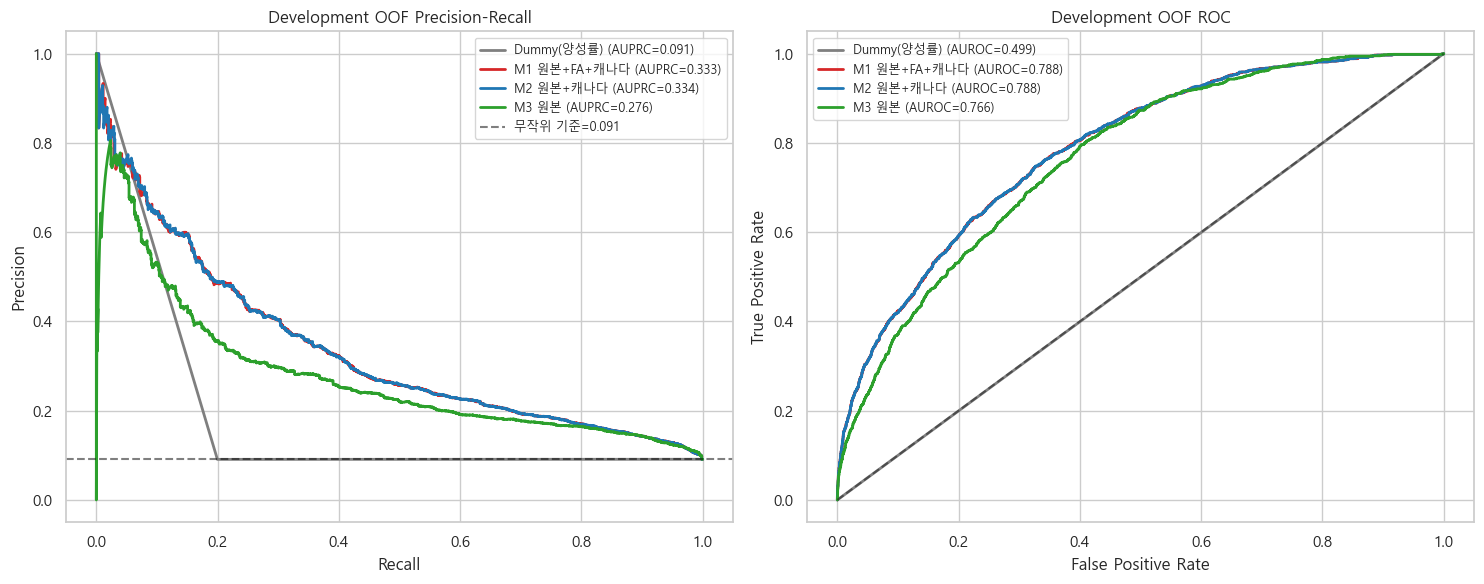

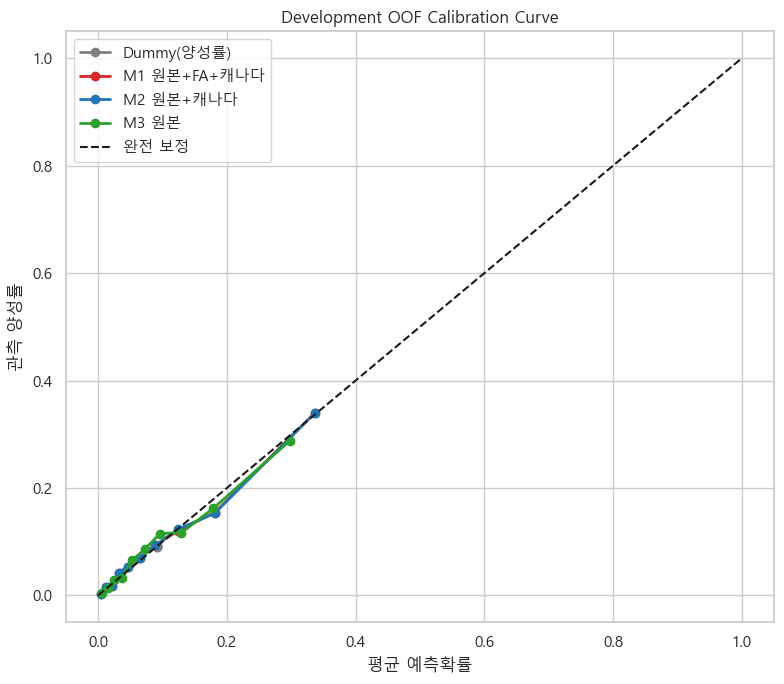

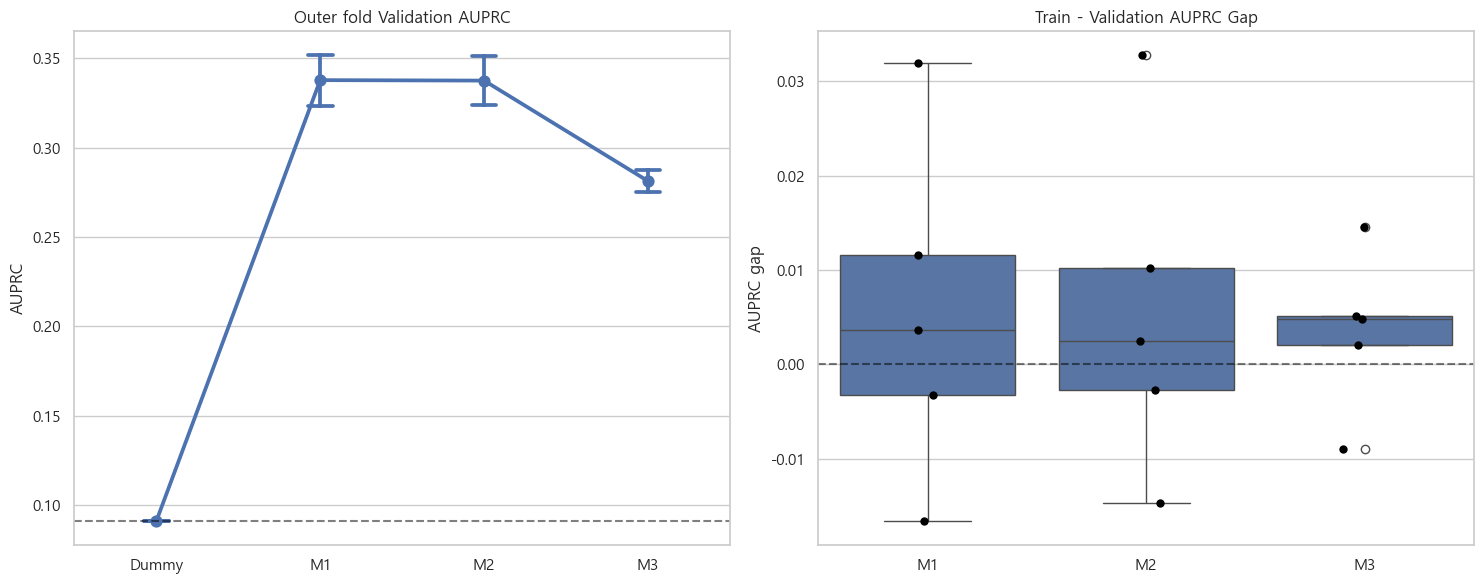

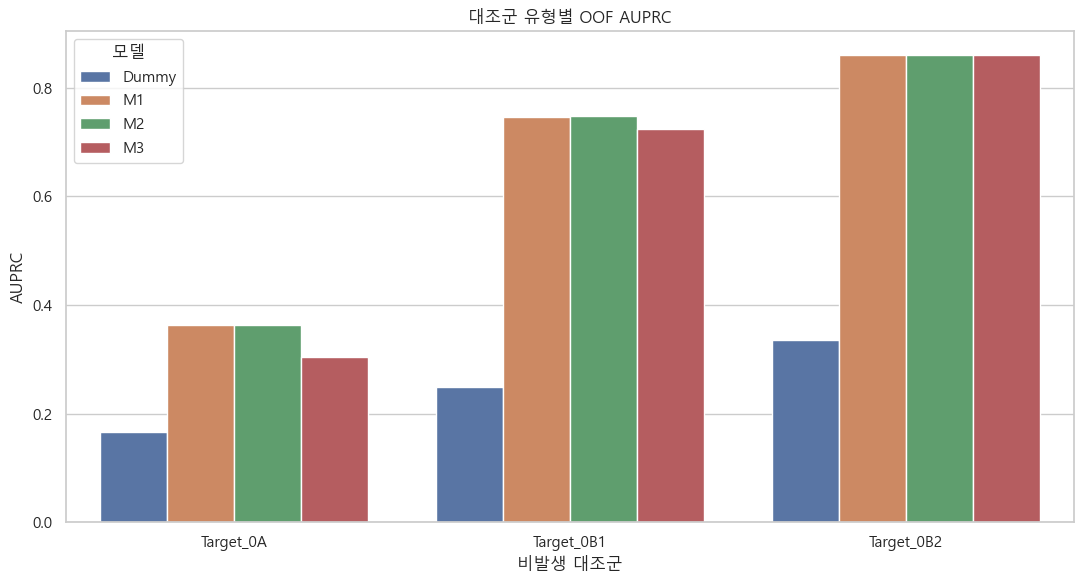

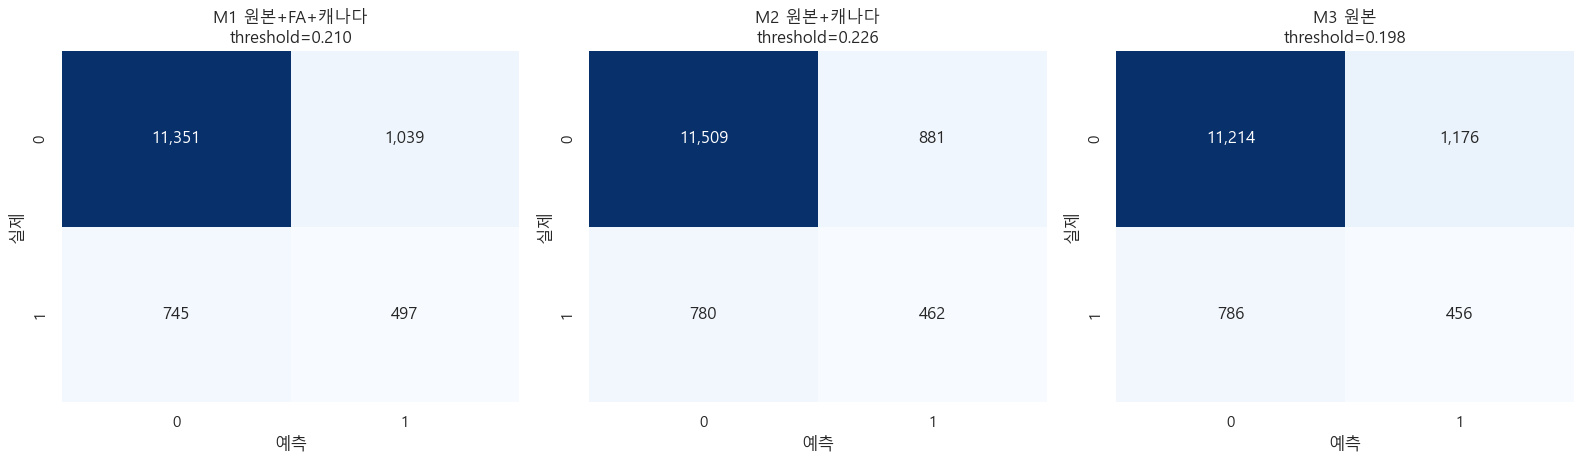

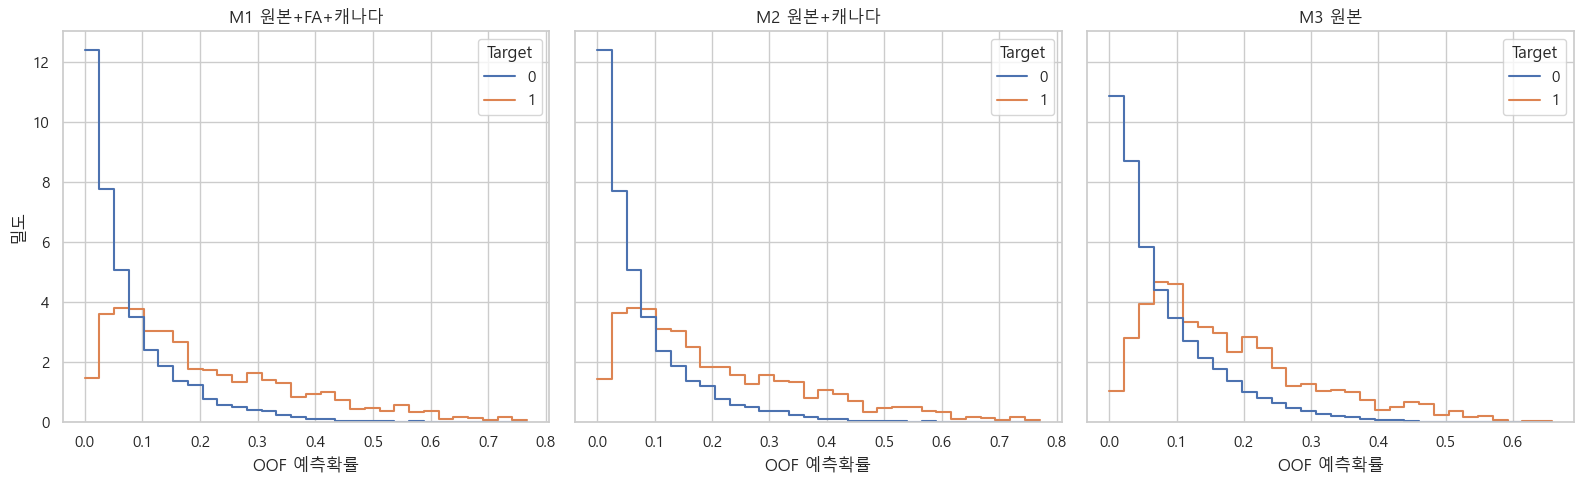

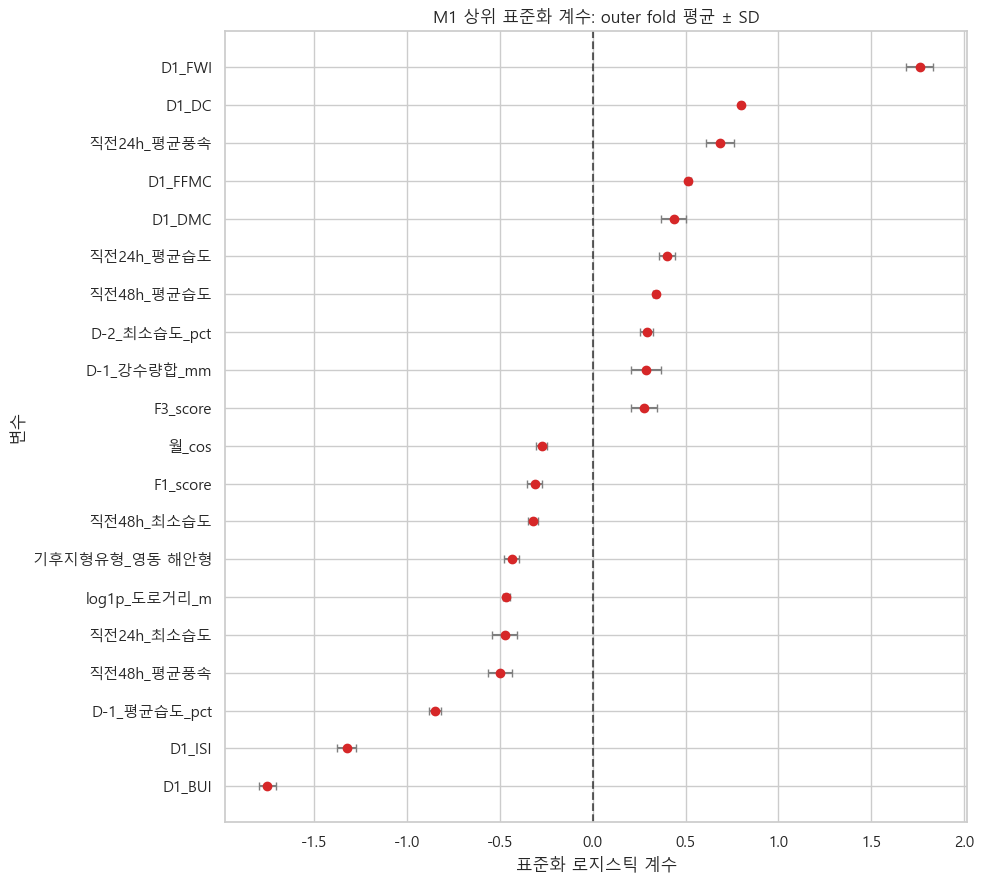

플롯 저장 위치: D:\farm-system-public-02\jsw\Analysis\logistic\outputs\plots


In [9]:
# 1. PR / ROC
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for model_name in MODEL_ORDER:
    part = oof_predictions.loc[oof_predictions["model"].eq(model_name)]
    precision, recall, _ = precision_recall_curve(
        part["Target"], part["probability"]
    )
    fpr, tpr, _ = roc_curve(part["Target"], part["probability"])
    ap = average_precision_score(part["Target"], part["probability"])
    auc = roc_auc_score(part["Target"], part["probability"])
    axes[0].plot(
        recall,
        precision,
        label=f"{MODEL_LABELS[model_name]} (AUPRC={ap:.3f})",
        color=MODEL_COLORS[model_name],
        linewidth=2,
    )
    axes[1].plot(
        fpr,
        tpr,
        label=f"{MODEL_LABELS[model_name]} (AUROC={auc:.3f})",
        color=MODEL_COLORS[model_name],
        linewidth=2,
    )

baseline = modeling["Target"].mean()
axes[0].axhline(
    baseline, color="black", linestyle="--", alpha=0.5,
    label=f"무작위 기준={baseline:.3f}"
)
axes[0].set(title="Development OOF Precision-Recall", xlabel="Recall", ylabel="Precision")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[1].set(title="Development OOF ROC", xlabel="False Positive Rate", ylabel="True Positive Rate")
for ax in axes:
    ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(PLOT_DIR / "stage5_01_pr_roc_curves.png", dpi=180, bbox_inches="tight")
plt.show()

# 2. Calibration
fig, ax = plt.subplots(figsize=(8, 7))
for model_name in MODEL_ORDER:
    part = oof_predictions.loc[oof_predictions["model"].eq(model_name)]
    observed, predicted = calibration_curve(
        part["Target"],
        part["probability"],
        n_bins=10,
        strategy="quantile",
    )
    ax.plot(
        predicted,
        observed,
        marker="o",
        linewidth=2,
        label=f"{MODEL_LABELS[model_name]}",
        color=MODEL_COLORS[model_name],
    )
ax.plot([0, 1], [0, 1], "k--", label="완전 보정")
ax.set(
    title="Development OOF Calibration Curve",
    xlabel="평균 예측확률",
    ylabel="관측 양성률",
)
ax.legend()
fig.tight_layout()
fig.savefig(PLOT_DIR / "stage5_02_calibration.png", dpi=180, bbox_inches="tight")
plt.show()

# 3. Fold AUPRC 및 generalization gap
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.pointplot(
    data=validation_fold_metrics,
    x="model",
    y="auprc",
    order=MODEL_ORDER,
    errorbar="sd",
    capsize=0.15,
    ax=axes[0],
)
axes[0].axhline(baseline, color="black", linestyle="--", alpha=0.5)
axes[0].set(title="Outer fold Validation AUPRC", xlabel="", ylabel="AUPRC")

sns.boxplot(
    data=generalization_gap.loc[generalization_gap["model"].ne("Dummy")],
    x="model",
    y="auprc_gap_train_minus_val",
    order=["M1", "M2", "M3"],
    ax=axes[1],
)
sns.stripplot(
    data=generalization_gap.loc[generalization_gap["model"].ne("Dummy")],
    x="model",
    y="auprc_gap_train_minus_val",
    order=["M1", "M2", "M3"],
    color="black",
    size=6,
    ax=axes[1],
)
axes[1].axhline(0, color="black", linestyle="--", alpha=0.5)
axes[1].set(
    title="Train - Validation AUPRC Gap",
    xlabel="",
    ylabel="AUPRC gap",
)
fig.tight_layout()
fig.savefig(PLOT_DIR / "stage5_03_fold_stability.png", dpi=180, bbox_inches="tight")
plt.show()

# 4. Negative type
fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(
    data=negative_type_metrics,
    x="negative_type",
    y="auprc",
    hue="model",
    hue_order=MODEL_ORDER,
    ax=ax,
)
ax.set(
    title="대조군 유형별 OOF AUPRC",
    xlabel="비발생 대조군",
    ylabel="AUPRC",
)
ax.legend(title="모델")
fig.tight_layout()
fig.savefig(PLOT_DIR / "stage5_04_negative_type_auprc.png", dpi=180, bbox_inches="tight")
plt.show()

# 5. Confusion matrices at OOF best-F1 threshold
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for ax, model_name in zip(axes, ["M1", "M2", "M3"]):
    part = oof_predictions.loc[oof_predictions["model"].eq(model_name)]
    threshold = threshold_lookup[model_name]["oof_best_f1"]
    pred = (part["probability"].to_numpy() >= threshold).astype(int)
    cm = confusion_matrix(part["Target"], pred, labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=ax)
    ax.set(
        title=f"{MODEL_LABELS[model_name]}\nthreshold={threshold:.3f}",
        xlabel="예측",
        ylabel="실제",
    )
fig.tight_layout()
fig.savefig(PLOT_DIR / "stage5_05_confusion_matrices.png", dpi=180, bbox_inches="tight")
plt.show()

# 6. Probability distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, model_name in zip(axes, ["M1", "M2", "M3"]):
    part = oof_predictions.loc[oof_predictions["model"].eq(model_name)]
    sns.histplot(
        data=part,
        x="probability",
        hue="Target",
        bins=30,
        stat="density",
        common_norm=False,
        element="step",
        fill=False,
        ax=ax,
    )
    ax.set(
        title=MODEL_LABELS[model_name],
        xlabel="OOF 예측확률",
        ylabel="밀도",
    )
fig.tight_layout()
fig.savefig(PLOT_DIR / "stage5_06_probability_distribution.png", dpi=180, bbox_inches="tight")
plt.show()

# 7. M1 top coefficients
m1_top = (
    coefficient_summary.loc[coefficient_summary["model"].eq("M1")]
    .nlargest(20, "abs_coefficient_mean")
    .sort_values("coefficient_mean")
)
fig, ax = plt.subplots(figsize=(10, 9))
ax.errorbar(
    m1_top["coefficient_mean"],
    m1_top["feature"],
    xerr=m1_top["coefficient_sd"].fillna(0),
    fmt="o",
    color="#d62728",
    ecolor="#7f7f7f",
    capsize=3,
)
ax.axvline(0, color="black", linestyle="--", alpha=0.6)
ax.set(
    title="M1 상위 표준화 계수: outer fold 평균 ± SD",
    xlabel="표준화 로지스틱 계수",
    ylabel="변수",
)
fig.tight_layout()
fig.savefig(PLOT_DIR / "stage5_07_m1_top_coefficients.png", dpi=180, bbox_inches="tight")
plt.show()

print("플롯 저장 위치:", PLOT_DIR)

### 5-4. 자동 결과 요약

Outer fold의 paired 차이와 전체 OOF 성능을 이용해 5단계 핵심 결과를 요약하고 Markdown 파일로 저장한다.

In [10]:
fold_pivot = validation_fold_metrics.pivot(
    index="outer_fold",
    columns="model",
    values=["auprc", "auroc", "brier"],
)

paired_rows = []
for left_model, right_model, comparison in [
    ("M1", "M2", "M1-M2_FA추가효과"),
    ("M2", "M3", "M2-M3_캐나다추가효과"),
]:
    for metric in ["auprc", "auroc", "brier"]:
        difference = (
            fold_pivot[metric][left_model]
            - fold_pivot[metric][right_model]
        )
        paired_rows.append(
            {
                "comparison": comparison,
                "metric": metric,
                "mean_difference": float(difference.mean()),
                "sd_difference": float(difference.std()),
                "min_difference": float(difference.min()),
                "max_difference": float(difference.max()),
                "positive_fold_count": int((difference > 0).sum()),
            }
        )
paired_comparison = pd.DataFrame(paired_rows)
paired_comparison.to_csv(
    METRIC_DIR / "stage5_paired_model_differences.csv",
    index=False,
    encoding="utf-8-sig",
)

overall_indexed = overall_metrics.set_index("model")
negative_indexed = negative_type_metrics.set_index(
    ["model", "negative_type"]
)
threshold_indexed = threshold_metrics_table.set_index(
    ["model", "threshold_type"]
)
fold_indexed = fold_summary.set_index("model")

m1_m2_auprc = float(
    overall_indexed.loc["M1", "auprc"]
    - overall_indexed.loc["M2", "auprc"]
)
m2_m3_auprc = float(
    overall_indexed.loc["M2", "auprc"]
    - overall_indexed.loc["M3", "auprc"]
)
m2_m3_0a = float(
    negative_indexed.loc[("M2", "Target_0A"), "auprc"]
    - negative_indexed.loc[("M3", "Target_0A"), "auprc"]
)

summary_lines = [
    "# 5단계 L2 로지스틱 기준 모델 결과 요약",
    "",
    "## 전체 OOF 성능",
    "",
    f"- M1 AUPRC/AUROC: {overall_indexed.loc['M1', 'auprc']:.4f} / {overall_indexed.loc['M1', 'auroc']:.4f}",
    f"- M2 AUPRC/AUROC: {overall_indexed.loc['M2', 'auprc']:.4f} / {overall_indexed.loc['M2', 'auroc']:.4f}",
    f"- M3 AUPRC/AUROC: {overall_indexed.loc['M3', 'auprc']:.4f} / {overall_indexed.loc['M3', 'auroc']:.4f}",
    f"- M1-M2 전체 AUPRC 차이: {m1_m2_auprc:+.6f}",
    f"- M2-M3 전체 AUPRC 차이: {m2_m3_auprc:+.4f}",
    "",
    "## 현재 판단",
    "",
    "- M1과 M2 성능은 사실상 동일하다. 원본 변수와 캐나다 지수가 있는 상태에서 FA 요인점수의 추가 예측력은 확인되지 않았다.",
    f"- 캐나다 지수를 추가한 M2는 M3보다 전체 AUPRC가 {m2_m3_auprc:+.4f} 높다.",
    f"- 가장 어려운 0-A 비교에서도 M2-M3 AUPRC 차이는 {m2_m3_0a:+.4f}이다.",
    f"- M2 calibration slope는 {overall_indexed.loc['M2', 'calibration_slope']:.3f}, intercept는 {overall_indexed.loc['M2', 'calibration_intercept']:.3f}으로 전체 OOF 보정은 양호하다.",
    f"- M2 outer-fold AUPRC는 {fold_indexed.loc['M2', 'auprc_mean']:.4f} ± {fold_indexed.loc['M2', 'auprc_sd']:.4f}이다.",
    "",
    "## 대조군 유형별 난이도",
    "",
    f"- M2 Target 0-A AUPRC: {negative_indexed.loc[('M2', 'Target_0A'), 'auprc']:.4f}",
    f"- M2 Target 0-B1 AUPRC: {negative_indexed.loc[('M2', 'Target_0B1'), 'auprc']:.4f}",
    f"- M2 Target 0-B2 AUPRC: {negative_indexed.loc[('M2', 'Target_0B2'), 'auprc']:.4f}",
    "- 공간 대조군보다 같은 산불 위치의 시간 대조군 0-A 구분이 훨씬 어렵다.",
    "",
    "## 임계값과 다음 단계 주의",
    "",
    f"- M2 OOF F1 최적 threshold는 {threshold_indexed.loc[('M2', 'oof_best_f1'), 'threshold']:.4f}, F1은 {threshold_indexed.loc[('M2', 'oof_best_f1'), 'f1']:.4f}이다.",
    f"- M2 Recall 90% threshold에서 precision은 {threshold_indexed.loc[('M2', 'oof_recall90'), 'precision']:.4f}이다.",
    "- 모든 outer fold에서 C=10이 선택되어 현재 탐색 상한에 걸렸다. 6단계에서는 C=100 이상을 포함해 규제 경계를 확장해야 한다.",
    "- FWI, ISI, BUI와 중복 습도·풍속 변수의 계수가 서로 반대 방향으로 크게 나타난다. 이는 다중공선성 신호이므로 5단계 계수를 개별 오즈비로 해석하지 않는다.",
    "- Lockbox test는 아직 사용하지 않았다.",
]

stage5_summary_text = "\n".join(summary_lines)
stage5_summary_path = OUTPUT_DIR / "stage5_result_summary.md"
stage5_summary_path.write_text(stage5_summary_text, encoding="utf-8")

from IPython.display import Markdown
display(Markdown(stage5_summary_text))
print("결과 요약 저장:", stage5_summary_path)
display(paired_comparison.round(6))

# 5단계 L2 로지스틱 기준 모델 결과 요약

## 전체 OOF 성능

- M1 AUPRC/AUROC: 0.3335 / 0.7877
- M2 AUPRC/AUROC: 0.3335 / 0.7877
- M3 AUPRC/AUROC: 0.2765 / 0.7661
- M1-M2 전체 AUPRC 차이: -0.000036
- M2-M3 전체 AUPRC 차이: +0.0570

## 현재 판단

- M1과 M2 성능은 사실상 동일하다. 원본 변수와 캐나다 지수가 있는 상태에서 FA 요인점수의 추가 예측력은 확인되지 않았다.
- 캐나다 지수를 추가한 M2는 M3보다 전체 AUPRC가 +0.0570 높다.
- 가장 어려운 0-A 비교에서도 M2-M3 AUPRC 차이는 +0.0596이다.
- M2 calibration slope는 0.968, intercept는 -0.060으로 전체 OOF 보정은 양호하다.
- M2 outer-fold AUPRC는 0.3375 ± 0.0136이다.

## 대조군 유형별 난이도

- M2 Target 0-A AUPRC: 0.3629
- M2 Target 0-B1 AUPRC: 0.7470
- M2 Target 0-B2 AUPRC: 0.8603
- 공간 대조군보다 같은 산불 위치의 시간 대조군 0-A 구분이 훨씬 어렵다.

## 임계값과 다음 단계 주의

- M2 OOF F1 최적 threshold는 0.2258, F1은 0.3574이다.
- M2 Recall 90% threshold에서 precision은 0.1430이다.
- 모든 outer fold에서 C=10이 선택되어 현재 탐색 상한에 걸렸다. 6단계에서는 C=100 이상을 포함해 규제 경계를 확장해야 한다.
- FWI, ISI, BUI와 중복 습도·풍속 변수의 계수가 서로 반대 방향으로 크게 나타난다. 이는 다중공선성 신호이므로 5단계 계수를 개별 오즈비로 해석하지 않는다.
- Lockbox test는 아직 사용하지 않았다.

결과 요약 저장: D:\farm-system-public-02\jsw\Analysis\logistic\outputs\stage5_result_summary.md


,comparison,metric,mean_difference,sd_difference,min_difference,max_difference,positive_fold_count
0,M1-M2_FA추가효과,auprc,0.000255,0.001358,-0.001208,0.002132,3
1,M1-M2_FA추가효과,auroc,-0.000005,0.000162,-0.000220,0.000194,3
2,M1-M2_FA추가효과,brier,0.000004,0.000013,-0.000015,0.000020,4
3,M2-M3_캐나다추가효과,auprc,0.056184,0.015478,0.034534,0.075264,5
4,M2-M3_캐나다추가효과,auroc,0.021678,0.003825,0.016730,0.026893,5
5,M2-M3_캐나다추가효과,brier,-0.002939,0.000572,-0.003635,-0.002088,0


### 5단계 해석 시 주의사항

- 모든 결과는 development OOF 기준이며 lockbox test는 아직 사용하지 않았다.
- 현재 양성 비율은 네거티브 샘플링으로 설계된 9.11%이므로 예측확률을 실제 산불 발생률로 해석하지 않는다.
- M1과 M2 차이는 FA의 추가 가치, M2와 M3 차이는 D-1 캐나다 지수의 추가 가치를 뜻한다.
- 0-B2 성능만 높고 0-A 성능이 낮다면 쉬운 계절·시간 배경을 구분한 것일 수 있다.
- 계수는 L2 규제와 상관 변수의 영향을 받으므로 이번 단계에서는 방향·안정성 진단용이다. 최종 오즈비는 축소 모델에서 별도로 계산한다.

## 6단계. FA 제외 후 정규화·class weight·캐나다 지수 축소 비교

5단계에서 M1과 M2의 성능 차이가 사실상 0이었으므로 **이 단계부터 FA 요인점수는 사용하지 않는다.**

6단계는 두 실험으로 구성한다.

1. `원본 날씨·공간 + D-1 캐나다 전체 지수`에서 정규화와 class weight 비교
   - L2 / L1 / Elastic Net
   - `class_weight=None` / `balanced`
   - 확장된 `C` 범위
2. 1번의 승자 정규화 방식으로 캐나다 지수 조합 축소
   - 전체 지수
   - FWI 단독
   - FFMC·DMC·DC
   - FFMC·ISI·BUI
   - 캐나다 지수 미사용

모든 비교는 기존 grouped outer/inner split을 그대로 사용하며 lockbox test는 계속 열지 않는다.

In [11]:
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

STAGE6_C_GRIDS = {
    "L2": [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],
    "L1": [0.01, 0.1, 1.0, 10.0, 100.0],
    "ElasticNet": [0.01, 0.1, 1.0, 10.0, 100.0],
}
STAGE6_L1_RATIOS = [0.1, 0.5, 0.9]
CLASS_WEIGHT_OPTIONS = {
    "none": None,
    "balanced": "balanced",
}


def make_penalized_pipeline(
    feature_list,
    family,
    c_value,
    class_weight_label,
    l1_ratio=None,
):
    categorical = [
        c for c in feature_manifest["categorical_features"] if c in feature_list
    ]
    numeric = [c for c in feature_list if c not in categorical]
    preprocessor = ColumnTransformer(
        transformers=[
            ("numeric", StandardScaler(), numeric),
            (
                "categorical",
                OneHotEncoder(
                    handle_unknown="ignore",
                    drop="first",
                    sparse_output=False,
                ),
                categorical,
            ),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )
    kwargs = {
        "C": float(c_value),
        "class_weight": CLASS_WEIGHT_OPTIONS[class_weight_label],
        "max_iter": 5000,
        "tol": 1e-3,
        "random_state": RANDOM_STATE,
    }
    if family == "L2":
        model = LogisticRegression(
            penalty="l2",
            solver="lbfgs",
            **kwargs,
        )
    elif family == "L1":
        model = LogisticRegression(
            penalty="l1",
            solver="saga",
            **kwargs,
        )
    elif family == "ElasticNet":
        model = LogisticRegression(
            penalty="elasticnet",
            solver="saga",
            l1_ratio=float(l1_ratio),
            **kwargs,
        )
    else:
        raise ValueError(f"지원하지 않는 family: {family}")
    return Pipeline([("preprocess", preprocessor), ("model", model)])


def configs_for_variant(family, class_weight_label):
    configs = []
    ratios = STAGE6_L1_RATIOS if family == "ElasticNet" else [None]
    for c_value in STAGE6_C_GRIDS[family]:
        for l1_ratio in ratios:
            configs.append(
                {
                    "family": family,
                    "class_weight": class_weight_label,
                    "C": float(c_value),
                    "l1_ratio": l1_ratio,
                }
            )
    return configs


REGULARIZATION_VARIANTS = [
    {
        "variant": f"{family}_{weight}",
        "family": family,
        "class_weight": weight,
    }
    for family in ["L2", "L1", "ElasticNet"]
    for weight in ["none", "balanced"]
]


def safe_subset_metrics(frame, probability_col="probability"):
    rows = []
    for negative_type in ["Target_0A", "Target_0B1", "Target_0B2"]:
        subset = frame.loc[
            frame["Target"].eq(1)
            | frame["샘플유형"].eq(negative_type)
        ]
        rows.append(
            {
                "negative_type": negative_type,
                **probability_metrics(
                    subset["Target"], subset[probability_col]
                ),
            }
        )
    return rows


def select_best_config(inner_result):
    summary = (
        inner_result.groupby(
            ["C", "l1_ratio_key"],
            observed=True,
            dropna=False,
        )
        .agg(
            mean_auprc=("auprc", "mean"),
            mean_0a_auprc=("auprc_0A", "mean"),
            mean_brier=("brier", "mean"),
        )
        .reset_index()
    )
    summary = summary.sort_values(
        ["mean_auprc", "mean_0a_auprc", "mean_brier", "C"],
        ascending=[False, False, True, True],
    )
    return summary.iloc[0].to_dict(), summary


print("정규화 후보:", [v["variant"] for v in REGULARIZATION_VARIANTS])
print("FA 변수 사용:", False)

정규화 후보: ['L2_none', 'L2_balanced', 'L1_none', 'L1_balanced', 'ElasticNet_none', 'ElasticNet_balanced']
FA 변수 사용: False


### 6-1. L2/L1/Elastic Net × class weight 비교

각 정규화 후보는 outer fold마다 inner 4-fold 전체 AUPRC를 우선하여 `C`와 `l1_ratio`를 선택한다. 동률에 가까운 경우 0-A AUPRC와 Brier score를 보조 기준으로 사용한다.

In [12]:
stage6_feature_list = feature_manifest["model_sets"]["M2"]
assert not any(feature.startswith("F") and feature.endswith("_score") for feature in stage6_feature_list)

reg_oof_rows = []
reg_fold_metric_rows = []
reg_tuning_rows = []
reg_selected_rows = []
reg_coefficient_rows = []

for outer_fold in range(5):
    outer_val_ids = outer_manifest.loc[
        outer_manifest["outer_fold"].eq(outer_fold), "샘플ID"
    ].tolist()
    outer_train_ids = outer_manifest.loc[
        ~outer_manifest["outer_fold"].eq(outer_fold), "샘플ID"
    ].tolist()
    train_df = modeling.loc[outer_train_ids]
    val_df = modeling.loc[outer_val_ids]
    inner_for_outer = inner_manifest.loc[
        inner_manifest["outer_fold"].eq(outer_fold)
    ].set_index("샘플ID")

    for variant_info in REGULARIZATION_VARIANTS:
        variant = variant_info["variant"]
        family = variant_info["family"]
        class_weight_label = variant_info["class_weight"]
        variant_inner_rows = []

        for config in configs_for_variant(family, class_weight_label):
            ratio_key = (
                float(config["l1_ratio"])
                if config["l1_ratio"] is not None
                else -1.0
            )
            for inner_fold in range(4):
                inner_val_ids = inner_for_outer.index[
                    inner_for_outer["inner_fold"].eq(inner_fold)
                ].tolist()
                inner_train_ids = inner_for_outer.index[
                    ~inner_for_outer["inner_fold"].eq(inner_fold)
                ].tolist()

                pipeline = make_penalized_pipeline(
                    stage6_feature_list,
                    family=family,
                    c_value=config["C"],
                    class_weight_label=class_weight_label,
                    l1_ratio=config["l1_ratio"],
                )
                pipeline.fit(
                    modeling.loc[inner_train_ids, stage6_feature_list],
                    modeling.loc[inner_train_ids, "Target"],
                )
                inner_probability = pipeline.predict_proba(
                    modeling.loc[inner_val_ids, stage6_feature_list]
                )[:, 1]
                inner_eval = modeling.loc[
                    inner_val_ids,
                    ["Target", "샘플유형"],
                ].copy()
                inner_eval["probability"] = inner_probability
                subset_0a = inner_eval.loc[
                    inner_eval["Target"].eq(1)
                    | inner_eval["샘플유형"].eq("Target_0A")
                ]
                result_row = {
                    "variant": variant,
                    "family": family,
                    "class_weight": class_weight_label,
                    "outer_fold": outer_fold,
                    "inner_fold": inner_fold,
                    "C": config["C"],
                    "l1_ratio": config["l1_ratio"],
                    "l1_ratio_key": ratio_key,
                    "auprc": float(
                        average_precision_score(
                            inner_eval["Target"],
                            inner_eval["probability"],
                        )
                    ),
                    "auprc_0A": float(
                        average_precision_score(
                            subset_0a["Target"],
                            subset_0a["probability"],
                        )
                    ),
                    "brier": float(
                        brier_score_loss(
                            inner_eval["Target"],
                            inner_eval["probability"],
                        )
                    ),
                }
                variant_inner_rows.append(result_row)
                reg_tuning_rows.append(result_row)

        best_config, config_summary = select_best_config(
            pd.DataFrame(variant_inner_rows)
        )
        selected_c = float(best_config["C"])
        selected_l1_ratio = (
            None
            if float(best_config["l1_ratio_key"]) < 0
            else float(best_config["l1_ratio_key"])
        )
        reg_selected_rows.append(
            {
                "variant": variant,
                "family": family,
                "class_weight": class_weight_label,
                "outer_fold": outer_fold,
                "selected_C": selected_c,
                "selected_l1_ratio": selected_l1_ratio,
                "inner_mean_auprc": float(best_config["mean_auprc"]),
                "inner_mean_0A_auprc": float(best_config["mean_0a_auprc"]),
                "inner_mean_brier": float(best_config["mean_brier"]),
            }
        )

        final_pipeline = make_penalized_pipeline(
            stage6_feature_list,
            family=family,
            c_value=selected_c,
            class_weight_label=class_weight_label,
            l1_ratio=selected_l1_ratio,
        )
        final_pipeline.fit(
            train_df[stage6_feature_list],
            train_df["Target"],
        )
        train_probability = final_pipeline.predict_proba(
            train_df[stage6_feature_list]
        )[:, 1]
        val_probability = final_pipeline.predict_proba(
            val_df[stage6_feature_list]
        )[:, 1]

        for sample_id, probability in zip(val_df["샘플ID"], val_probability):
            row = val_df.loc[sample_id]
            reg_oof_rows.append(
                {
                    "샘플ID": sample_id,
                    "variant": variant,
                    "family": family,
                    "class_weight": class_weight_label,
                    "outer_fold": outer_fold,
                    "Target": int(row["Target"]),
                    "샘플유형": row["샘플유형"],
                    "기후지형유형": row["기후지형유형"],
                    "probability": float(probability),
                    "selected_C": selected_c,
                    "selected_l1_ratio": selected_l1_ratio,
                }
            )

        for dataset_name, y_part, p_part in [
            ("train", train_df["Target"], train_probability),
            ("validation", val_df["Target"], val_probability),
        ]:
            reg_fold_metric_rows.append(
                {
                    "variant": variant,
                    "family": family,
                    "class_weight": class_weight_label,
                    "outer_fold": outer_fold,
                    "dataset": dataset_name,
                    "selected_C": selected_c,
                    "selected_l1_ratio": selected_l1_ratio,
                    **probability_metrics(y_part, p_part),
                }
            )

        feature_names = final_pipeline.named_steps[
            "preprocess"
        ].get_feature_names_out()
        coefficients = final_pipeline.named_steps["model"].coef_[0]
        for feature_name, coefficient in zip(feature_names, coefficients):
            reg_coefficient_rows.append(
                {
                    "variant": variant,
                    "family": family,
                    "class_weight": class_weight_label,
                    "outer_fold": outer_fold,
                    "feature": feature_name,
                    "coefficient": float(coefficient),
                    "selected": int(abs(coefficient) > 1e-8),
                }
            )

        print(
            f"outer={outer_fold} {variant}: "
            f"C={selected_c:g}, l1_ratio={selected_l1_ratio}, "
            f"val AUPRC={average_precision_score(val_df['Target'], val_probability):.4f}"
        )

reg_oof = pd.DataFrame(reg_oof_rows)
reg_fold_metrics = pd.DataFrame(reg_fold_metric_rows)
reg_tuning = pd.DataFrame(reg_tuning_rows)
reg_selected = pd.DataFrame(reg_selected_rows)
reg_coefficients = pd.DataFrame(reg_coefficient_rows)

assert len(reg_oof) == len(modeling) * len(REGULARIZATION_VARIANTS)
assert reg_oof.groupby(["variant", "샘플ID"]).size().eq(1).all()

reg_oof.to_csv(
    PREDICTION_DIR / "stage6_regularization_oof_predictions.csv",
    index=False,
    encoding="utf-8-sig",
)
reg_fold_metrics.to_csv(
    METRIC_DIR / "stage6_regularization_fold_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)
reg_tuning.to_csv(
    METRIC_DIR / "stage6_regularization_inner_tuning.csv",
    index=False,
    encoding="utf-8-sig",
)
reg_selected.to_csv(
    METRIC_DIR / "stage6_regularization_selected_params.csv",
    index=False,
    encoding="utf-8-sig",
)
reg_coefficients.to_csv(
    COEFFICIENT_DIR / "stage6_regularization_fold_coefficients.csv",
    index=False,
    encoding="utf-8-sig",
)

outer=0 L2_none: C=100, l1_ratio=None, val AUPRC=0.3500


outer=0 L2_balanced: C=1, l1_ratio=None, val AUPRC=0.2999


outer=0 L1_none: C=100, l1_ratio=None, val AUPRC=0.3531


outer=0 L1_balanced: C=100, l1_ratio=None, val AUPRC=0.2994


outer=0 ElasticNet_none: C=100, l1_ratio=0.9, val AUPRC=0.3531


...

outer=4 L2_balanced: C=10, l1_ratio=None, val AUPRC=0.2623


outer=4 L1_none: C=100, l1_ratio=None, val AUPRC=0.3147


outer=4 L1_balanced: C=1, l1_ratio=None, val AUPRC=0.2660


outer=4 ElasticNet_none: C=100, l1_ratio=0.1, val AUPRC=0.3147


outer=4 ElasticNet_balanced: C=1, l1_ratio=0.1, val AUPRC=0.2657


### 6-2. 정규화 후보 결과표와 승자 선택

전체 OOF AUPRC를 주 기준으로 정렬하고, 0-A AUPRC, Brier score와 calibration을 함께 확인한다.

In [13]:
reg_overall_rows = []
reg_negative_rows = []
reg_threshold_rows = []

for variant, part in reg_oof.groupby("variant", observed=True):
    reg_overall_rows.append(
        {
            "variant": variant,
            "family": part["family"].iloc[0],
            "class_weight": part["class_weight"].iloc[0],
            **probability_metrics(part["Target"], part["probability"]),
        }
    )
    for row in safe_subset_metrics(part):
        reg_negative_rows.append(
            {
                "variant": variant,
                "family": part["family"].iloc[0],
                "class_weight": part["class_weight"].iloc[0],
                **row,
            }
        )
    best_f1_threshold, recall90_threshold = choose_thresholds(
        part["Target"], part["probability"]
    )
    for threshold_type, threshold in {
        "oof_best_f1": best_f1_threshold,
        "oof_recall90": recall90_threshold,
    }.items():
        reg_threshold_rows.append(
            {
                "variant": variant,
                "threshold_type": threshold_type,
                **threshold_metrics(
                    part["Target"],
                    part["probability"],
                    threshold,
                ),
            }
        )

reg_overall = pd.DataFrame(reg_overall_rows).sort_values(
    ["auprc", "brier"],
    ascending=[False, True],
)
reg_negative = pd.DataFrame(reg_negative_rows)
reg_thresholds = pd.DataFrame(reg_threshold_rows)

reg_fold_validation = reg_fold_metrics.loc[
    reg_fold_metrics["dataset"].eq("validation")
]
reg_fold_summary = (
    reg_fold_validation.groupby(
        ["variant", "family", "class_weight"],
        observed=True,
    )
    .agg(
        auprc_mean=("auprc", "mean"),
        auprc_sd=("auprc", "std"),
        auroc_mean=("auroc", "mean"),
        auroc_sd=("auroc", "std"),
        brier_mean=("brier", "mean"),
        brier_sd=("brier", "std"),
    )
    .reset_index()
)

reg_coefficient_summary = (
    reg_coefficients.groupby(["variant", "feature"], observed=True)
    .agg(
        coefficient_mean=("coefficient", "mean"),
        coefficient_sd=("coefficient", "std"),
        selection_rate=("selected", "mean"),
        positive_fold_rate=("coefficient", lambda s: float((s > 0).mean())),
    )
    .reset_index()
)
reg_coefficient_summary["abs_coefficient_mean"] = reg_coefficient_summary[
    "coefficient_mean"
].abs()

winner_variant = str(reg_overall.iloc[0]["variant"])
winner_family = str(reg_overall.iloc[0]["family"])
winner_class_weight = str(reg_overall.iloc[0]["class_weight"])

reg_overall.to_csv(
    METRIC_DIR / "stage6_regularization_overall_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)
reg_negative.to_csv(
    METRIC_DIR / "stage6_regularization_negative_type_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)
reg_thresholds.to_csv(
    METRIC_DIR / "stage6_regularization_threshold_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)
reg_fold_summary.to_csv(
    METRIC_DIR / "stage6_regularization_fold_summary.csv",
    index=False,
    encoding="utf-8-sig",
)
reg_coefficient_summary.to_csv(
    COEFFICIENT_DIR / "stage6_regularization_coefficient_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

print("정규화 후보 전체 OOF 성능")
display(reg_overall.round(4))
print("0-A/0-B1/0-B2 성능")
display(
    reg_negative[
        [
            "variant",
            "negative_type",
            "auprc",
            "auroc",
            "brier",
        ]
    ].round(4)
)
print("선택된 하이퍼파라미터")
display(reg_selected)
print("정규화 승자:", winner_variant)

정규화 후보 전체 OOF 성능


,variant,family,class_weight,n,positive_n,positive_rate,auprc,auroc,brier,log_loss,calibration_intercept,calibration_slope
5,L2_none,L2,none,13632,1242,0.0911,0.3339,0.7852,0.0720,0.2567,-0.0699,0.9625
1,ElasticNet_none,ElasticNet,none,13632,1242,0.0911,0.3325,0.7874,0.0720,0.2563,-0.0507,0.9736
3,L1_none,L1,none,13632,1242,0.0911,0.3324,0.7874,0.0720,0.2563,-0.0499,0.9741
2,L1_balanced,L1,balanced,13632,1242,0.0911,0.2785,0.7902,0.1915,0.5576,-2.2829,0.9222
0,ElasticNet_balanced,ElasticNet,balanced,13632,1242,0.0911,0.2785,0.7902,0.1915,0.5576,-2.2827,0.9214
4,L2_balanced,L2,balanced,13632,1242,0.0911,0.2781,0.7894,0.1916,0.5577,-2.2807,0.9182


0-A/0-B1/0-B2 성능


,variant,negative_type,auprc,auroc,brier
0,ElasticNet_balanced,Target_0A,0.3069,0.6741,0.2744
1,ElasticNet_balanced,Target_0B1,0.7490,0.8929,0.1231
2,ElasticNet_balanced,Target_0B2,0.8638,0.9256,0.1089
3,ElasticNet_none,Target_0A,0.3616,0.6812,0.1284
4,ElasticNet_none,Target_0B1,0.7477,0.8781,0.1677
5,ElasticNet_none,Target_0B2,0.8622,0.9163,0.2195
6,L1_balanced,Target_0A,0.3070,0.6742,0.2744
7,L1_balanced,Target_0B1,0.7491,0.8929,0.1231
8,L1_balanced,Target_0B2,0.8636,0.9256,0.1089
9,L1_none,Target_0A,0.3614,0.6812,0.1285


선택된 하이퍼파라미터


,variant,family,class_weight,outer_fold,selected_C,selected_l1_ratio,inner_mean_auprc,inner_mean_0A_auprc,inner_mean_brier
0,L2_none,L2,none,0,100.0,NaN,0.328395,0.356690,0.072457
1,L2_balanced,L2,balanced,0,1.0,NaN,0.274281,0.301360,0.192818
2,L1_none,L1,none,0,100.0,NaN,0.326534,0.355019,0.072522
3,L1_balanced,L1,balanced,0,100.0,NaN,0.275168,0.303765,0.191861
4,ElasticNet_none,ElasticNet,none,0,100.0,0.9,0.326533,0.355017,0.072522
5,ElasticNet_balanced,ElasticNet,balanced,0,100.0,0.1,0.275179,0.303775,0.191861
6,L2_none,L2,none,1,100.0,NaN,0.338624,0.367769,0.071918
7,L2_balanced,L2,balanced,1,1000.0,NaN,0.284736,0.312625,0.190554
8,L1_none,L1,none,1,100.0,NaN,0.336517,0.365980,0.071985
9,L1_balanced,L1,balanced,1,10.0,NaN,0.285041,0.313874,0.190231


정규화 승자: L2_none


### 6-3. 승자 정규화 방식으로 캐나다 지수 조합 축소

정규화 실험의 승자 family와 class weight를 고정하고, 각 캐나다 지수 조합에서 `C`와 필요 시 `l1_ratio`만 inner CV로 다시 선택한다.

In [14]:
base_features = feature_manifest["model_sets"]["M3"]
category_feature = feature_manifest["categorical_features"][0]
base_without_category = [c for c in base_features if c != category_feature]

CANADIAN_SUBSETS = {
    "CAN_ALL": feature_manifest["canadian_features"],
    "CAN_FWI_ONLY": ["D1_FWI"],
    "CAN_FFMC_DMC_DC": ["D1_FFMC", "D1_DMC", "D1_DC"],
    "CAN_FFMC_ISI_BUI": ["D1_FFMC", "D1_ISI", "D1_BUI"],
    "NO_CANADA": [],
}
subset_feature_sets = {
    subset_name: base_without_category + canadian_cols + [category_feature]
    for subset_name, canadian_cols in CANADIAN_SUBSETS.items()
}

subset_oof_rows = []
subset_fold_metric_rows = []
subset_tuning_rows = []
subset_selected_rows = []
subset_coefficient_rows = []

for outer_fold in range(5):
    outer_val_ids = outer_manifest.loc[
        outer_manifest["outer_fold"].eq(outer_fold), "샘플ID"
    ].tolist()
    outer_train_ids = outer_manifest.loc[
        ~outer_manifest["outer_fold"].eq(outer_fold), "샘플ID"
    ].tolist()
    train_df = modeling.loc[outer_train_ids]
    val_df = modeling.loc[outer_val_ids]
    inner_for_outer = inner_manifest.loc[
        inner_manifest["outer_fold"].eq(outer_fold)
    ].set_index("샘플ID")

    for subset_name, feature_list in subset_feature_sets.items():
        subset_inner_rows = []
        configs = configs_for_variant(
            winner_family,
            winner_class_weight,
        )
        for config in configs:
            ratio_key = (
                float(config["l1_ratio"])
                if config["l1_ratio"] is not None
                else -1.0
            )
            for inner_fold in range(4):
                inner_val_ids = inner_for_outer.index[
                    inner_for_outer["inner_fold"].eq(inner_fold)
                ].tolist()
                inner_train_ids = inner_for_outer.index[
                    ~inner_for_outer["inner_fold"].eq(inner_fold)
                ].tolist()
                pipeline = make_penalized_pipeline(
                    feature_list,
                    family=winner_family,
                    c_value=config["C"],
                    class_weight_label=winner_class_weight,
                    l1_ratio=config["l1_ratio"],
                )
                pipeline.fit(
                    modeling.loc[inner_train_ids, feature_list],
                    modeling.loc[inner_train_ids, "Target"],
                )
                probability = pipeline.predict_proba(
                    modeling.loc[inner_val_ids, feature_list]
                )[:, 1]
                inner_eval = modeling.loc[
                    inner_val_ids, ["Target", "샘플유형"]
                ].copy()
                inner_eval["probability"] = probability
                subset_0a = inner_eval.loc[
                    inner_eval["Target"].eq(1)
                    | inner_eval["샘플유형"].eq("Target_0A")
                ]
                result_row = {
                    "subset": subset_name,
                    "outer_fold": outer_fold,
                    "inner_fold": inner_fold,
                    "family": winner_family,
                    "class_weight": winner_class_weight,
                    "C": config["C"],
                    "l1_ratio": config["l1_ratio"],
                    "l1_ratio_key": ratio_key,
                    "auprc": float(
                        average_precision_score(
                            inner_eval["Target"],
                            inner_eval["probability"],
                        )
                    ),
                    "auprc_0A": float(
                        average_precision_score(
                            subset_0a["Target"],
                            subset_0a["probability"],
                        )
                    ),
                    "brier": float(
                        brier_score_loss(
                            inner_eval["Target"],
                            inner_eval["probability"],
                        )
                    ),
                }
                subset_inner_rows.append(result_row)
                subset_tuning_rows.append(result_row)

        best_config, _ = select_best_config(
            pd.DataFrame(subset_inner_rows)
        )
        selected_c = float(best_config["C"])
        selected_l1_ratio = (
            None
            if float(best_config["l1_ratio_key"]) < 0
            else float(best_config["l1_ratio_key"])
        )
        subset_selected_rows.append(
            {
                "subset": subset_name,
                "outer_fold": outer_fold,
                "family": winner_family,
                "class_weight": winner_class_weight,
                "selected_C": selected_c,
                "selected_l1_ratio": selected_l1_ratio,
                "inner_mean_auprc": float(best_config["mean_auprc"]),
                "inner_mean_0A_auprc": float(best_config["mean_0a_auprc"]),
                "inner_mean_brier": float(best_config["mean_brier"]),
            }
        )

        final_pipeline = make_penalized_pipeline(
            feature_list,
            family=winner_family,
            c_value=selected_c,
            class_weight_label=winner_class_weight,
            l1_ratio=selected_l1_ratio,
        )
        final_pipeline.fit(
            train_df[feature_list],
            train_df["Target"],
        )
        train_probability = final_pipeline.predict_proba(
            train_df[feature_list]
        )[:, 1]
        val_probability = final_pipeline.predict_proba(
            val_df[feature_list]
        )[:, 1]

        for sample_id, probability in zip(val_df["샘플ID"], val_probability):
            row = val_df.loc[sample_id]
            subset_oof_rows.append(
                {
                    "샘플ID": sample_id,
                    "subset": subset_name,
                    "outer_fold": outer_fold,
                    "Target": int(row["Target"]),
                    "샘플유형": row["샘플유형"],
                    "기후지형유형": row["기후지형유형"],
                    "probability": float(probability),
                    "selected_C": selected_c,
                    "selected_l1_ratio": selected_l1_ratio,
                }
            )

        for dataset_name, y_part, p_part in [
            ("train", train_df["Target"], train_probability),
            ("validation", val_df["Target"], val_probability),
        ]:
            subset_fold_metric_rows.append(
                {
                    "subset": subset_name,
                    "outer_fold": outer_fold,
                    "dataset": dataset_name,
                    "family": winner_family,
                    "class_weight": winner_class_weight,
                    **probability_metrics(y_part, p_part),
                }
            )

        feature_names = final_pipeline.named_steps[
            "preprocess"
        ].get_feature_names_out()
        coefficients = final_pipeline.named_steps["model"].coef_[0]
        for feature_name, coefficient in zip(feature_names, coefficients):
            subset_coefficient_rows.append(
                {
                    "subset": subset_name,
                    "outer_fold": outer_fold,
                    "feature": feature_name,
                    "coefficient": float(coefficient),
                    "selected": int(abs(coefficient) > 1e-8),
                }
            )
        print(
            f"outer={outer_fold} {subset_name}: "
            f"C={selected_c:g}, l1_ratio={selected_l1_ratio}, "
            f"val AUPRC={average_precision_score(val_df['Target'], val_probability):.4f}"
        )

subset_oof = pd.DataFrame(subset_oof_rows)
subset_fold_metrics = pd.DataFrame(subset_fold_metric_rows)
subset_tuning = pd.DataFrame(subset_tuning_rows)
subset_selected = pd.DataFrame(subset_selected_rows)
subset_coefficients = pd.DataFrame(subset_coefficient_rows)

assert len(subset_oof) == len(modeling) * len(CANADIAN_SUBSETS)
assert subset_oof.groupby(["subset", "샘플ID"]).size().eq(1).all()

subset_oof.to_csv(
    PREDICTION_DIR / "stage6_canadian_subset_oof_predictions.csv",
    index=False,
    encoding="utf-8-sig",
)
subset_fold_metrics.to_csv(
    METRIC_DIR / "stage6_canadian_subset_fold_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)
subset_tuning.to_csv(
    METRIC_DIR / "stage6_canadian_subset_inner_tuning.csv",
    index=False,
    encoding="utf-8-sig",
)
subset_selected.to_csv(
    METRIC_DIR / "stage6_canadian_subset_selected_params.csv",
    index=False,
    encoding="utf-8-sig",
)
subset_coefficients.to_csv(
    COEFFICIENT_DIR / "stage6_canadian_subset_fold_coefficients.csv",
    index=False,
    encoding="utf-8-sig",
)

outer=0 CAN_ALL: C=100, l1_ratio=None, val AUPRC=0.3500


outer=0 CAN_FWI_ONLY: C=1000, l1_ratio=None, val AUPRC=0.2968


outer=0 CAN_FFMC_DMC_DC: C=1000, l1_ratio=None, val AUPRC=0.2923


outer=0 CAN_FFMC_ISI_BUI: C=1000, l1_ratio=None, val AUPRC=0.2890


outer=0 NO_CANADA: C=1000, l1_ratio=None, val AUPRC=0.2794


...

outer=4 CAN_ALL: C=1000, l1_ratio=None, val AUPRC=0.3163


outer=4 CAN_FWI_ONLY: C=100, l1_ratio=None, val AUPRC=0.2695


outer=4 CAN_FFMC_DMC_DC: C=100, l1_ratio=None, val AUPRC=0.2629


outer=4 CAN_FFMC_ISI_BUI: C=1000, l1_ratio=None, val AUPRC=0.2726


outer=4 NO_CANADA: C=1, l1_ratio=None, val AUPRC=0.2833


### 6-4. 캐나다 지수 조합 결과표와 변수 안정성

In [15]:
subset_overall_rows = []
subset_negative_rows = []
subset_threshold_rows = []

for subset_name, part in subset_oof.groupby("subset", observed=True):
    subset_overall_rows.append(
        {
            "subset": subset_name,
            **probability_metrics(part["Target"], part["probability"]),
        }
    )
    for row in safe_subset_metrics(part):
        subset_negative_rows.append({"subset": subset_name, **row})
    best_f1_threshold, recall90_threshold = choose_thresholds(
        part["Target"], part["probability"]
    )
    for threshold_type, threshold in {
        "oof_best_f1": best_f1_threshold,
        "oof_recall90": recall90_threshold,
    }.items():
        subset_threshold_rows.append(
            {
                "subset": subset_name,
                "threshold_type": threshold_type,
                **threshold_metrics(
                    part["Target"], part["probability"], threshold
                ),
            }
        )

subset_overall = pd.DataFrame(subset_overall_rows).sort_values(
    ["auprc", "brier"],
    ascending=[False, True],
)
subset_negative = pd.DataFrame(subset_negative_rows)
subset_thresholds = pd.DataFrame(subset_threshold_rows)
subset_fold_validation = subset_fold_metrics.loc[
    subset_fold_metrics["dataset"].eq("validation")
]
subset_fold_summary = (
    subset_fold_validation.groupby("subset", observed=True)
    .agg(
        auprc_mean=("auprc", "mean"),
        auprc_sd=("auprc", "std"),
        auroc_mean=("auroc", "mean"),
        auroc_sd=("auroc", "std"),
        brier_mean=("brier", "mean"),
        brier_sd=("brier", "std"),
    )
    .reset_index()
)
subset_coefficient_summary = (
    subset_coefficients.groupby(["subset", "feature"], observed=True)
    .agg(
        coefficient_mean=("coefficient", "mean"),
        coefficient_sd=("coefficient", "std"),
        selection_rate=("selected", "mean"),
        positive_fold_rate=("coefficient", lambda s: float((s > 0).mean())),
    )
    .reset_index()
)
subset_coefficient_summary["abs_coefficient_mean"] = (
    subset_coefficient_summary["coefficient_mean"].abs()
)

best_subset = str(subset_overall.iloc[0]["subset"])

subset_overall.to_csv(
    METRIC_DIR / "stage6_canadian_subset_overall_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)
subset_negative.to_csv(
    METRIC_DIR / "stage6_canadian_subset_negative_type_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)
subset_thresholds.to_csv(
    METRIC_DIR / "stage6_canadian_subset_threshold_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)
subset_fold_summary.to_csv(
    METRIC_DIR / "stage6_canadian_subset_fold_summary.csv",
    index=False,
    encoding="utf-8-sig",
)
subset_coefficient_summary.to_csv(
    COEFFICIENT_DIR / "stage6_canadian_subset_coefficient_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

print("캐나다 지수 조합 전체 OOF 성능")
display(subset_overall.round(4))
print("대조군 유형별 성능")
display(
    subset_negative[
        ["subset", "negative_type", "auprc", "auroc", "brier"]
    ].round(4)
)
print("선택된 하이퍼파라미터")
display(subset_selected)
print("캐나다 지수 조합 승자:", best_subset)

캐나다 지수 조합 전체 OOF 성능


,subset,n,positive_n,positive_rate,auprc,auroc,brier,log_loss,calibration_intercept,calibration_slope
0,CAN_ALL,13632,1242,0.0911,0.3339,0.7852,0.0720,0.2567,-0.0699,0.9625
3,CAN_FWI_ONLY,13632,1242,0.0911,0.2773,0.7714,0.0747,0.2637,-0.0770,0.9618
4,NO_CANADA,13632,1242,0.0911,0.2763,0.7647,0.0749,0.2657,-0.0762,0.9594
2,CAN_FFMC_ISI_BUI,13632,1242,0.0911,0.2751,0.7729,0.0746,0.2633,-0.0774,0.9620
1,CAN_FFMC_DMC_DC,13632,1242,0.0911,0.2733,0.7763,0.0746,0.2626,-0.0777,0.9619


대조군 유형별 성능


,subset,negative_type,auprc,auroc,brier
0,CAN_ALL,Target_0A,0.3628,0.6785,0.1285
1,CAN_ALL,Target_0B1,0.7464,0.8762,0.1677
2,CAN_ALL,Target_0B2,0.8606,0.9146,0.2194
3,CAN_FFMC_DMC_DC,Target_0A,0.3006,0.6543,0.1333
4,CAN_FFMC_DMC_DC,Target_0B1,0.7354,0.8817,0.1745
5,CAN_FFMC_DMC_DC,Target_0B2,0.8622,0.9223,0.2286
6,CAN_FFMC_ISI_BUI,Target_0A,0.3022,0.6495,0.1333
7,CAN_FFMC_ISI_BUI,Target_0B1,0.7328,0.8790,0.1749
8,CAN_FFMC_ISI_BUI,Target_0B2,0.8623,0.9215,0.2290
9,CAN_FWI_ONLY,Target_0A,0.3042,0.6458,0.1335


선택된 하이퍼파라미터


,subset,outer_fold,family,class_weight,selected_C,selected_l1_ratio,inner_mean_auprc,inner_mean_0A_auprc,inner_mean_brier
0,CAN_ALL,0,L2,none,100.0,None,0.328395,0.356690,0.072457
1,CAN_FWI_ONLY,0,L2,none,1000.0,None,0.280181,0.306334,0.074921
2,CAN_FFMC_DMC_DC,0,L2,none,1000.0,None,0.274373,0.300624,0.074920
3,CAN_FFMC_ISI_BUI,0,L2,none,1000.0,None,0.276262,0.302492,0.074856
4,NO_CANADA,0,L2,none,1000.0,None,0.275348,0.301140,0.075189
5,CAN_ALL,1,L2,none,100.0,None,0.338624,0.367769,0.071918
6,CAN_FWI_ONLY,1,L2,none,1.0,None,0.291831,0.320714,0.074346
7,CAN_FFMC_DMC_DC,1,L2,none,100.0,None,0.284158,0.312639,0.074323
8,CAN_FFMC_ISI_BUI,1,L2,none,1000.0,None,0.286937,0.314766,0.074293
9,NO_CANADA,1,L2,none,1000.0,None,0.281893,0.310412,0.074832


캐나다 지수 조합 승자: CAN_ALL


### 6-5. 정규화·캐나다 지수 축소 상세 플롯

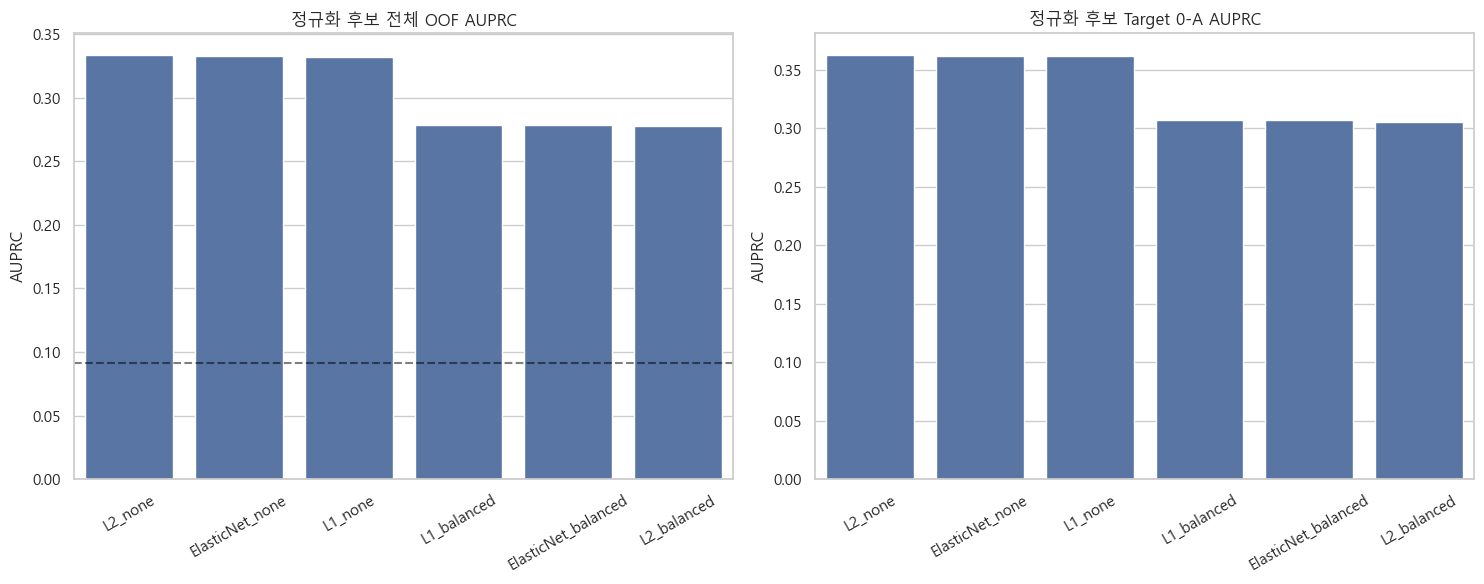

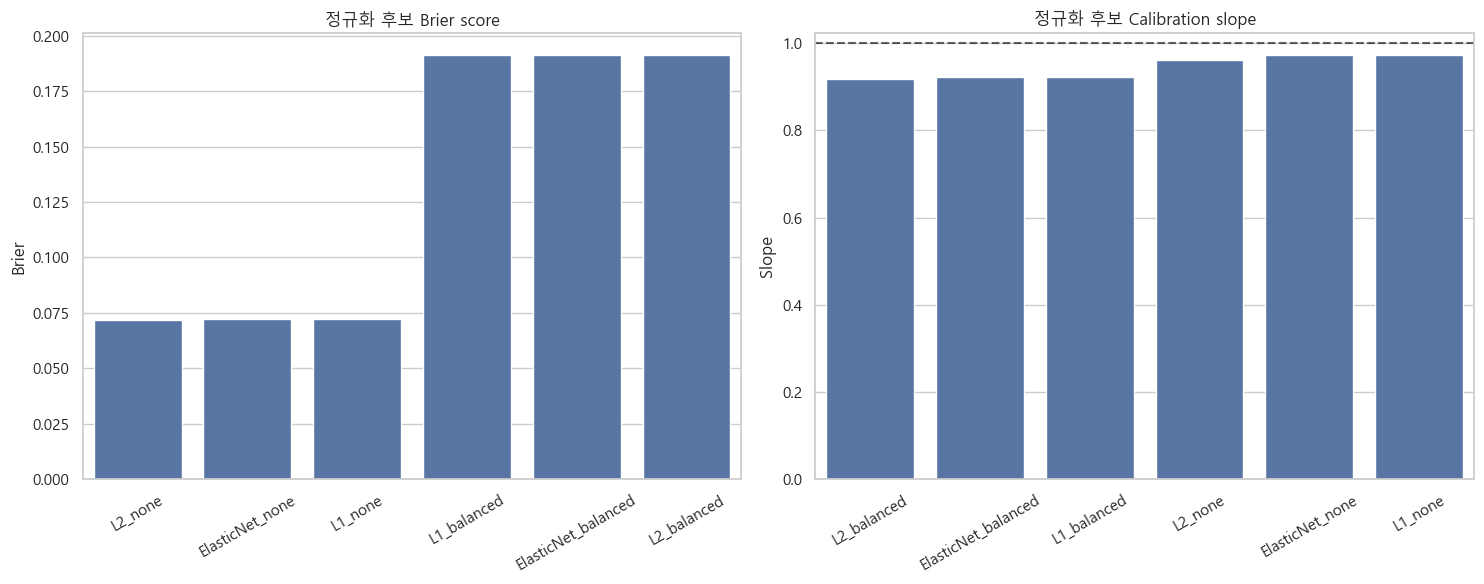

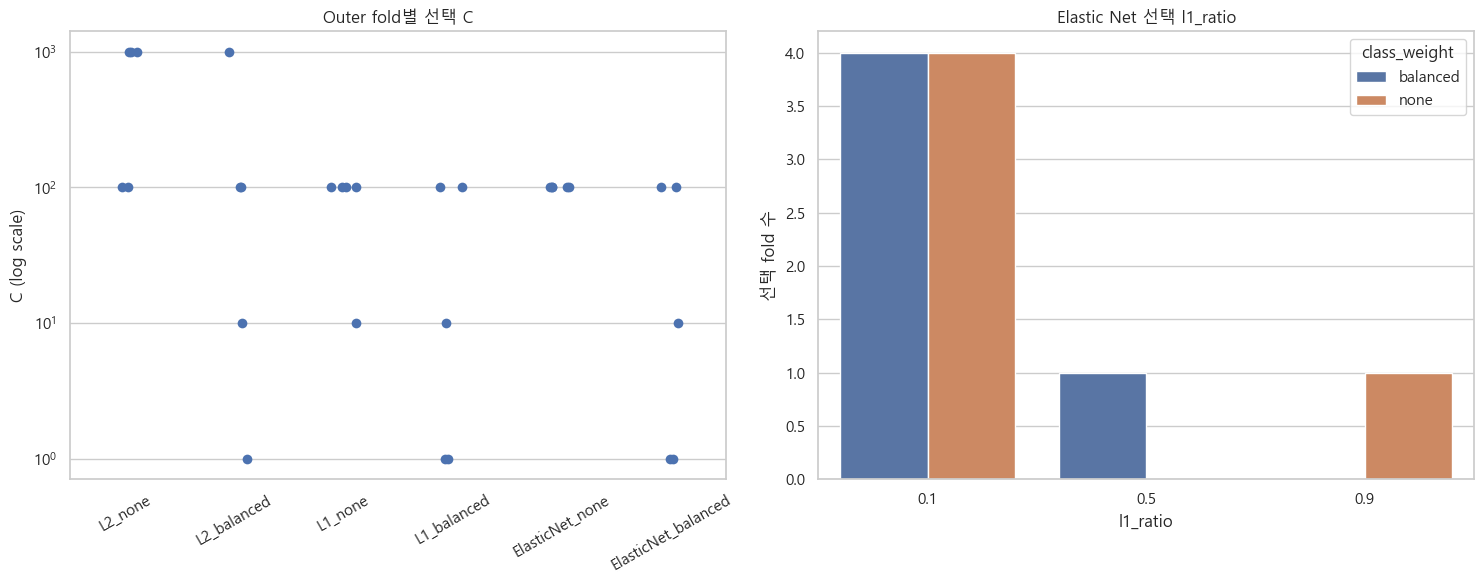

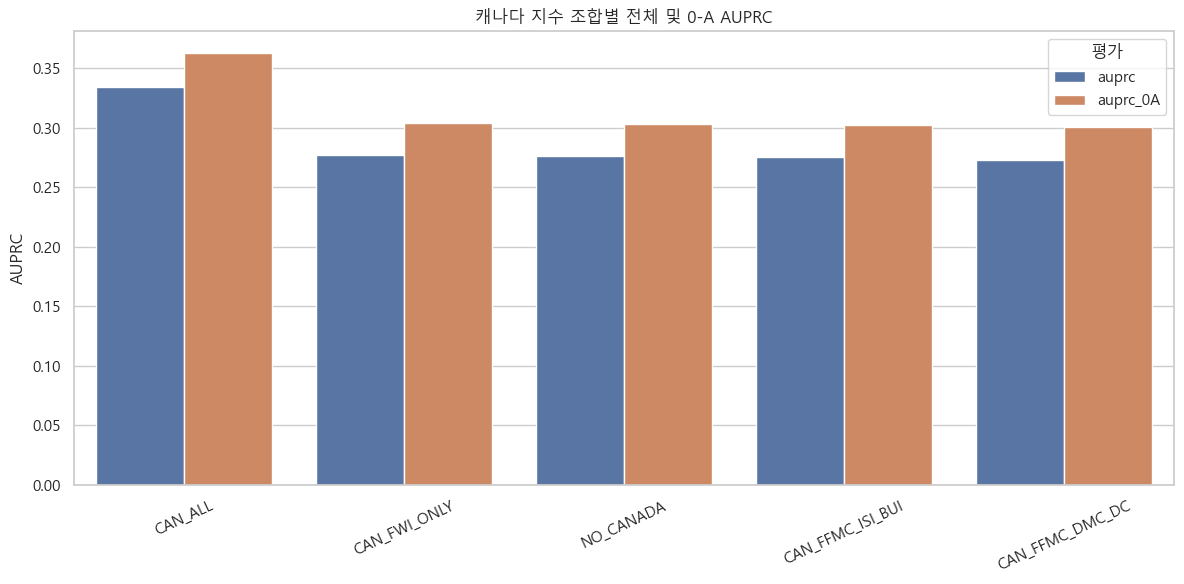

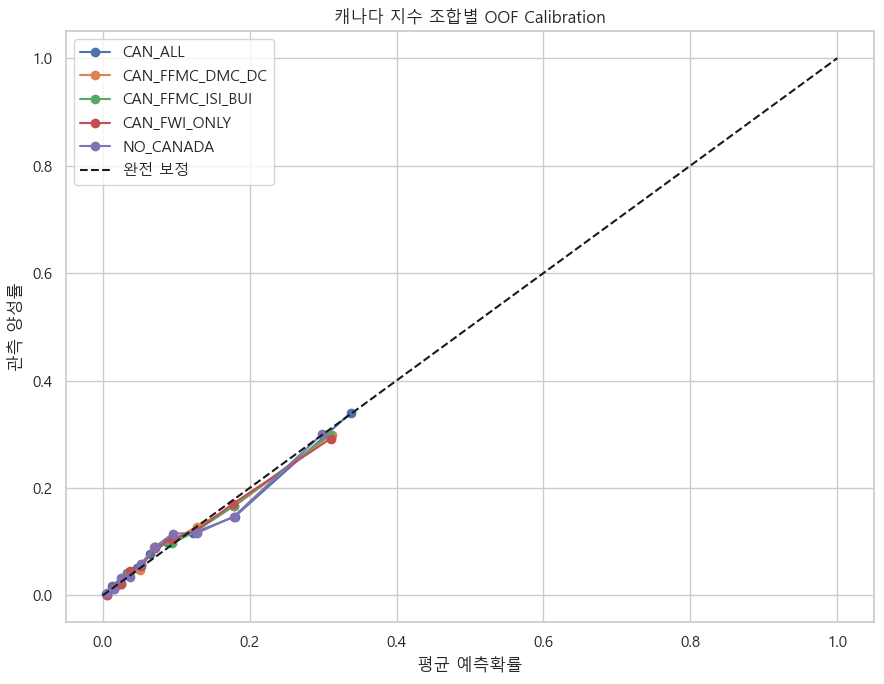

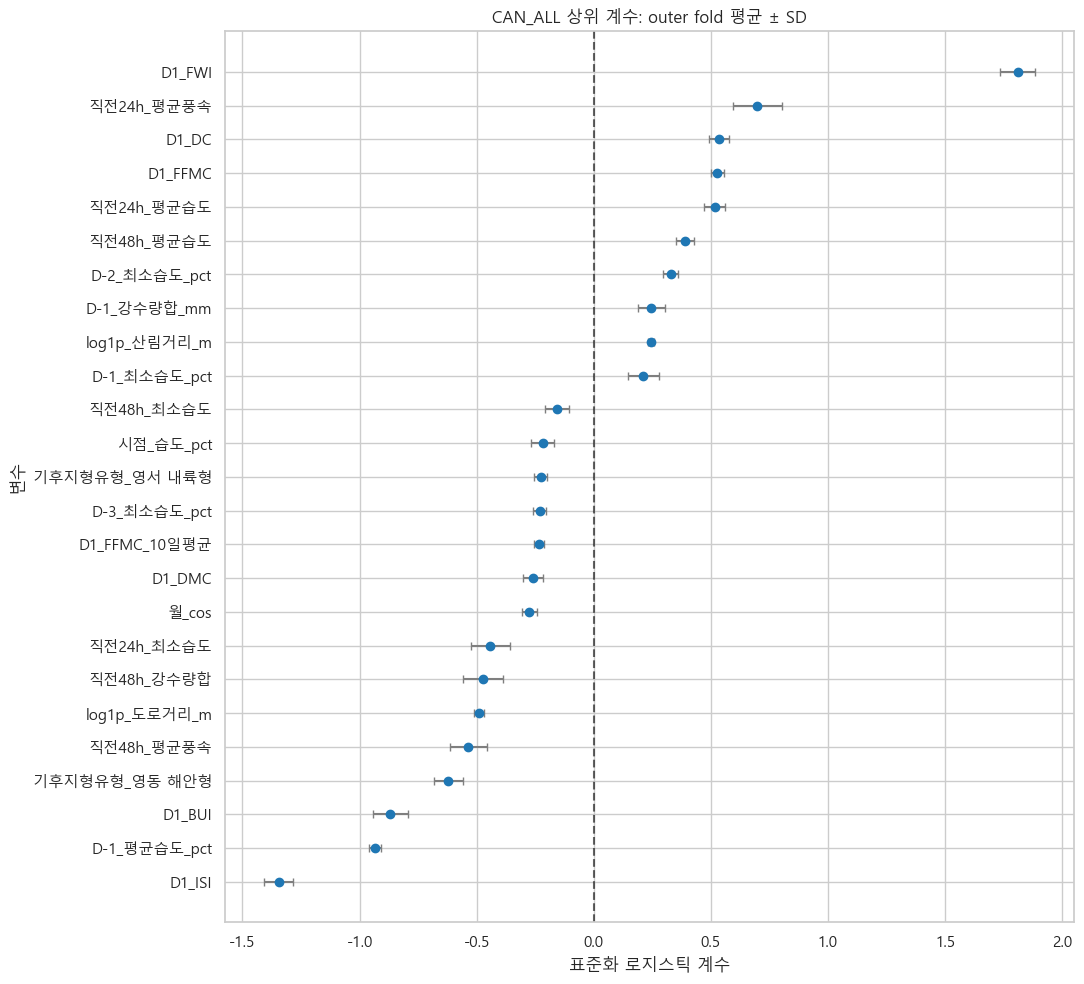

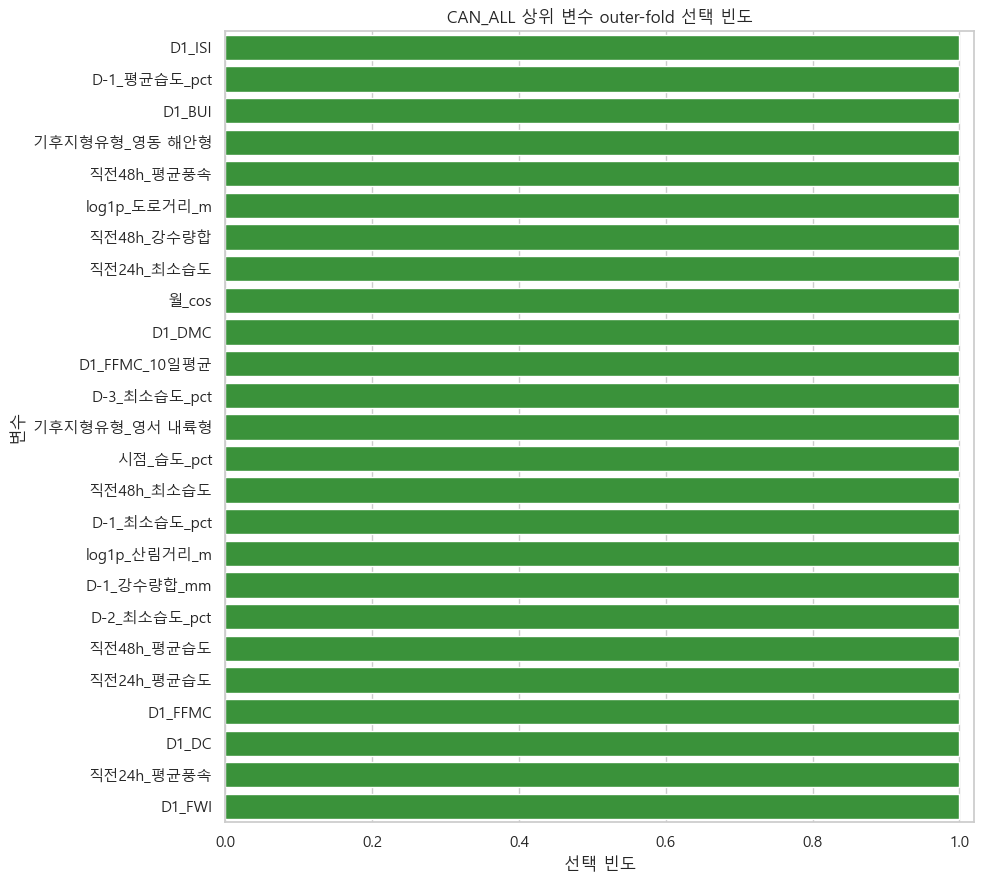

In [16]:
# 1. 정규화 전체 AUPRC와 0-A AUPRC
reg_0a = reg_negative.loc[
    reg_negative["negative_type"].eq("Target_0A"),
    ["variant", "auprc"],
].rename(columns={"auprc": "auprc_0A"})
reg_plot = reg_overall.merge(reg_0a, on="variant", how="left")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(
    data=reg_plot,
    x="variant",
    y="auprc",
    order=reg_plot.sort_values("auprc", ascending=False)["variant"],
    ax=axes[0],
)
axes[0].axhline(modeling["Target"].mean(), color="black", linestyle="--", alpha=0.5)
axes[0].tick_params(axis="x", rotation=30)
axes[0].set(title="정규화 후보 전체 OOF AUPRC", xlabel="", ylabel="AUPRC")

sns.barplot(
    data=reg_plot,
    x="variant",
    y="auprc_0A",
    order=reg_plot.sort_values("auprc_0A", ascending=False)["variant"],
    ax=axes[1],
)
axes[1].tick_params(axis="x", rotation=30)
axes[1].set(title="정규화 후보 Target 0-A AUPRC", xlabel="", ylabel="AUPRC")
fig.tight_layout()
fig.savefig(PLOT_DIR / "stage6_01_regularization_auprc.png", dpi=180, bbox_inches="tight")
plt.show()

# 2. Brier와 calibration slope
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(
    data=reg_overall,
    x="variant",
    y="brier",
    order=reg_overall.sort_values("brier")["variant"],
    ax=axes[0],
)
axes[0].tick_params(axis="x", rotation=30)
axes[0].set(title="정규화 후보 Brier score", xlabel="", ylabel="Brier")
sns.barplot(
    data=reg_overall,
    x="variant",
    y="calibration_slope",
    order=reg_overall.sort_values("calibration_slope")["variant"],
    ax=axes[1],
)
axes[1].axhline(1, color="black", linestyle="--", alpha=0.6)
axes[1].tick_params(axis="x", rotation=30)
axes[1].set(title="정규화 후보 Calibration slope", xlabel="", ylabel="Slope")
fig.tight_layout()
fig.savefig(PLOT_DIR / "stage6_02_regularization_calibration.png", dpi=180, bbox_inches="tight")
plt.show()

# 3. 선택 하이퍼파라미터
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.stripplot(
    data=reg_selected,
    x="variant",
    y="selected_C",
    jitter=0.12,
    size=7,
    ax=axes[0],
)
axes[0].set_yscale("log")
axes[0].tick_params(axis="x", rotation=30)
axes[0].set(title="Outer fold별 선택 C", xlabel="", ylabel="C (log scale)")
elastic_selected = reg_selected.loc[
    reg_selected["family"].eq("ElasticNet")
]
sns.countplot(
    data=elastic_selected,
    x="selected_l1_ratio",
    hue="class_weight",
    ax=axes[1],
)
axes[1].set(title="Elastic Net 선택 l1_ratio", xlabel="l1_ratio", ylabel="선택 fold 수")
fig.tight_layout()
fig.savefig(PLOT_DIR / "stage6_03_selected_hyperparameters.png", dpi=180, bbox_inches="tight")
plt.show()

# 4. 캐나다 조합 전체 / 0-A AUPRC
subset_0a = subset_negative.loc[
    subset_negative["negative_type"].eq("Target_0A"),
    ["subset", "auprc"],
].rename(columns={"auprc": "auprc_0A"})
subset_plot = subset_overall.merge(subset_0a, on="subset", how="left")
subset_long = subset_plot.melt(
    id_vars="subset",
    value_vars=["auprc", "auprc_0A"],
    var_name="평가",
    value_name="AUPRC",
)
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=subset_long,
    x="subset",
    y="AUPRC",
    hue="평가",
    ax=ax,
)
ax.tick_params(axis="x", rotation=25)
ax.set(title="캐나다 지수 조합별 전체 및 0-A AUPRC", xlabel="", ylabel="AUPRC")
fig.tight_layout()
fig.savefig(PLOT_DIR / "stage6_04_canadian_subsets_auprc.png", dpi=180, bbox_inches="tight")
plt.show()

# 5. 캐나다 조합 calibration
fig, ax = plt.subplots(figsize=(9, 7))
for subset_name, part in subset_oof.groupby("subset", observed=True):
    observed, predicted = calibration_curve(
        part["Target"],
        part["probability"],
        n_bins=10,
        strategy="quantile",
    )
    ax.plot(predicted, observed, marker="o", label=subset_name)
ax.plot([0, 1], [0, 1], "k--", label="완전 보정")
ax.set(
    title="캐나다 지수 조합별 OOF Calibration",
    xlabel="평균 예측확률",
    ylabel="관측 양성률",
)
ax.legend()
fig.tight_layout()
fig.savefig(PLOT_DIR / "stage6_05_canadian_subsets_calibration.png", dpi=180, bbox_inches="tight")
plt.show()

# 6. 최종 후보 계수 안정성
best_coefs = subset_coefficient_summary.loc[
    subset_coefficient_summary["subset"].eq(best_subset)
].copy()
best_coefs = best_coefs.nlargest(25, "abs_coefficient_mean").sort_values(
    "coefficient_mean"
)
fig, ax = plt.subplots(figsize=(11, 10))
ax.errorbar(
    best_coefs["coefficient_mean"],
    best_coefs["feature"],
    xerr=best_coefs["coefficient_sd"].fillna(0),
    fmt="o",
    color="#1f77b4",
    ecolor="#7f7f7f",
    capsize=3,
)
ax.axvline(0, color="black", linestyle="--", alpha=0.6)
ax.set(
    title=f"{best_subset} 상위 계수: outer fold 평균 ± SD",
    xlabel="표준화 로지스틱 계수",
    ylabel="변수",
)
fig.tight_layout()
fig.savefig(PLOT_DIR / "stage6_06_best_subset_coefficients.png", dpi=180, bbox_inches="tight")
plt.show()

# 7. 선택 빈도
selection_plot = best_coefs.sort_values("selection_rate")
fig, ax = plt.subplots(figsize=(10, 9))
sns.barplot(
    data=selection_plot,
    x="selection_rate",
    y="feature",
    color="#2ca02c",
    ax=ax,
)
ax.set(
    xlim=(0, 1.02),
    title=f"{best_subset} 상위 변수 outer-fold 선택 빈도",
    xlabel="선택 빈도",
    ylabel="변수",
)
fig.tight_layout()
fig.savefig(PLOT_DIR / "stage6_07_best_subset_selection_rate.png", dpi=180, bbox_inches="tight")
plt.show()

### 6-6. 자동 결과 요약

In [17]:
winner_reg = reg_overall.set_index("variant").loc[winner_variant]
winner_reg_0a = reg_negative.set_index(
    ["variant", "negative_type"]
).loc[(winner_variant, "Target_0A")]
best_subset_row = subset_overall.set_index("subset").loc[best_subset]
best_subset_0a = subset_negative.set_index(
    ["subset", "negative_type"]
).loc[(best_subset, "Target_0A")]
no_canada_row = subset_overall.set_index("subset").loc["NO_CANADA"]
no_canada_0a = subset_negative.set_index(
    ["subset", "negative_type"]
).loc[("NO_CANADA", "Target_0A")]

summary_lines = [
    "# 6단계 정규화·캐나다 지수 축소 결과 요약",
    "",
    "## FA 제외 결정",
    "",
    "- 5단계에서 FA 추가 효과가 사실상 0이었으므로 6단계부터 FA 요인점수는 사용하지 않았다.",
    "",
    "## 정규화 승자",
    "",
    f"- 승자: {winner_variant}",
    f"- 전체 OOF AUPRC/AUROC: {winner_reg['auprc']:.4f} / {winner_reg['auroc']:.4f}",
    f"- Brier / calibration slope: {winner_reg['brier']:.5f} / {winner_reg['calibration_slope']:.3f}",
    f"- Target 0-A AUPRC: {winner_reg_0a['auprc']:.4f}",
    "",
    "## 캐나다 지수 축소 승자",
    "",
    f"- 승자 조합: {best_subset}",
    f"- 전체 OOF AUPRC/AUROC: {best_subset_row['auprc']:.4f} / {best_subset_row['auroc']:.4f}",
    f"- Target 0-A AUPRC: {best_subset_0a['auprc']:.4f}",
    f"- 캐나다 미사용 대비 전체 AUPRC 차이: {best_subset_row['auprc'] - no_canada_row['auprc']:+.4f}",
    f"- 캐나다 미사용 대비 0-A AUPRC 차이: {best_subset_0a['auprc'] - no_canada_0a['auprc']:+.4f}",
    "",
    "## 다음 판단 기준",
    "",
    "- 전체 AUPRC뿐 아니라 0-A AUPRC, Brier, calibration과 변수 선택 안정성을 함께 본다.",
    "- 지수 조합 간 성능 차이가 0.005 미만이면 더 단순하고 계수 충돌이 적은 조합을 우선한다.",
    "- 이번 단계에서도 lockbox test는 사용하지 않았다.",
]
stage6_summary_text = "\n".join(summary_lines)
stage6_summary_path = OUTPUT_DIR / "stage6_result_summary.md"
stage6_summary_path.write_text(stage6_summary_text, encoding="utf-8")

display(Markdown(stage6_summary_text))
print("결과 요약 저장:", stage6_summary_path)

# 6단계 정규화·캐나다 지수 축소 결과 요약

## FA 제외 결정

- 5단계에서 FA 추가 효과가 사실상 0이었으므로 6단계부터 FA 요인점수는 사용하지 않았다.

## 정규화 승자

- 승자: L2_none
- 전체 OOF AUPRC/AUROC: 0.3339 / 0.7852
- Brier / calibration slope: 0.07202 / 0.963
- Target 0-A AUPRC: 0.3628

## 캐나다 지수 축소 승자

- 승자 조합: CAN_ALL
- 전체 OOF AUPRC/AUROC: 0.3339 / 0.7852
- Target 0-A AUPRC: 0.3628
- 캐나다 미사용 대비 전체 AUPRC 차이: +0.0576
- 캐나다 미사용 대비 0-A AUPRC 차이: +0.0594

## 다음 판단 기준

- 전체 AUPRC뿐 아니라 0-A AUPRC, Brier, calibration과 변수 선택 안정성을 함께 본다.
- 지수 조합 간 성능 차이가 0.005 미만이면 더 단순하고 계수 충돌이 적은 조합을 우선한다.
- 이번 단계에서도 lockbox test는 사용하지 않았다.

결과 요약 저장: D:\farm-system-public-02\jsw\Analysis\logistic\outputs\stage6_result_summary.md


## 7단계. EDA 핵심 피처 확장

6단계 최종 후보인 `L2 + class_weight 없음 + D-1 캐나다 전체 지수`에 국지 저습, 무강수 지속, 6시간 풍속과 권역 상호작용을 추가한다. FA 요인점수는 사용하지 않는다.

In [1]:
from pathlib import Path
import runpy

RUN_STAGE7 = False
stage7_script = Path.cwd() / "stage7_feature_extension.py"
if RUN_STAGE7:
    runpy.run_path(str(stage7_script), run_name="__main__")
else:
    print("기존 stage7 산출물을 사용합니다.")
    print("재계산하려면 RUN_STAGE7 = True로 변경하세요.")

기존 stage7 산출물을 사용합니다.
재계산하려면 RUN_STAGE7 = True로 변경하세요.


In [2]:
from pathlib import Path
import pandas as pd
from IPython.display import Markdown, display

analysis_dir = Path.cwd()
output_dir = analysis_dir / "outputs"
metric_dir = output_dir / "metrics"

display(Markdown((output_dir / "stage7_result_summary.md").read_text(encoding="utf-8")))
comparison = pd.read_csv(metric_dir / "stage7_feature_set_comparison.csv", encoding="utf-8-sig")
negative = pd.read_csv(metric_dir / "stage7_feature_set_negative_type_metrics.csv", encoding="utf-8-sig")
climate = pd.read_csv(metric_dir / "stage7_feature_set_climate_metrics.csv", encoding="utf-8-sig")

print("피처 세트 비교")
display(comparison.round(4))
print("대조군 유형별 성능")
display(negative[["feature_set", "negative_type", "auprc", "auroc", "brier"]].round(4))
print("기후지형유형별 성능")
display(climate[["feature_set", "기후지형유형", "auprc", "auroc", "brier"]].round(4))

# 7단계 EDA 피처 확장 결과 요약

## 피처 계산 정책

- 기준시각 이전 6시간 풍속만 사용했다.
- 무강수 지속시간은 기준시각 이전 마지막 0.1mm/5.0mm 이상 시간강수로부터 계산하고 720시간에서 상한 처리했다.
- 국지 하위 5% 습도 기준은 기상셀×월×시간대의 2020~2021 고정 기후분포를 사용했다.
- FFMC/ISI 결합 플래그는 미래 누수를 피하기 위해 D-1 정오 지수를 사용했다.
- FA 요인점수는 사용하지 않았다.

## 결과

- 수치상 최상위 피처 세트: PLUS_ALL_INTERACTIONS
- 전체 AUPRC: 0.3759
- Target 0-A AUPRC: 0.4103
- BASE 대비 전체 ΔAUPRC: +0.0420
- BASE 대비 0-A ΔAUPRC: +0.0475
- BASE 대비 Brier 변화: -0.00235
- 복잡도 반영 최종 추천 세트: PLUS_CONTINUOUS_FLAGS
- 추천 세트 전체/0-A AUPRC: 0.3751 / 0.4088
- 수치상 1위 대비 추천 세트 전체 AUPRC 차이: -0.0008

## 판단 기준

- 전체 및 0-A AUPRC가 모두 개선되고 Brier가 악화되지 않을 때 신규 피처를 유지한다.
- 개선 폭이 0.005 미만이면 복잡성을 고려해 기존 BASE 모델을 우선한다.
- 상호작용 전체 세트의 추가 이득이 0.005 미만이므로, 후속 모델은 연속형+EDA 플래그 세트를 우선한다.
- lockbox test는 사용하지 않았다.

피처 세트 비교


,feature_set,n,positive_n,positive_rate,auprc,auroc,brier,log_loss,delta_auprc_vs_base,delta_brier_vs_base,auprc_0A,delta_0A_auprc_vs_base
0,PLUS_ALL_INTERACTIONS,13632,1242,0.0911,0.3759,0.7982,0.0697,0.2487,0.0420,-0.0023,0.4103,0.0475
1,PLUS_CONTINUOUS_FLAGS,13632,1242,0.0911,0.3751,0.7953,0.0698,0.2496,0.0412,-0.0022,0.4088,0.0460
2,PLUS_FLAGS,13632,1242,0.0911,0.3646,0.7939,0.0703,0.2508,0.0307,-0.0017,0.3986,0.0358
3,PLUS_CONTINUOUS,13632,1242,0.0911,0.3514,0.7895,0.0712,0.2545,0.0175,-0.0009,0.3816,0.0188
4,BASE_CAN_ALL,13632,1242,0.0911,0.3339,0.7852,0.0720,0.2567,0.0000,0.0000,0.3628,0.0000


대조군 유형별 성능


,feature_set,negative_type,auprc,auroc,brier
0,BASE_CAN_ALL,Target_0A,0.3628,0.6785,0.1285
1,BASE_CAN_ALL,Target_0B1,0.7464,0.8762,0.1677
2,BASE_CAN_ALL,Target_0B2,0.8606,0.9146,0.2194
3,PLUS_ALL_INTERACTIONS,Target_0A,0.4103,0.7014,0.1238
4,PLUS_ALL_INTERACTIONS,Target_0B1,0.7552,0.8830,0.1616
5,PLUS_ALL_INTERACTIONS,Target_0B2,0.8487,0.9125,0.2118
6,PLUS_CONTINUOUS,Target_0A,0.3816,0.6882,0.1267
7,PLUS_CONTINUOUS,Target_0B1,0.7518,0.8768,0.1652
8,PLUS_CONTINUOUS,Target_0B2,0.8532,0.9110,0.2163
9,PLUS_CONTINUOUS_FLAGS,Target_0A,0.4088,0.6960,0.1241


기후지형유형별 성능


,feature_set,기후지형유형,auprc,auroc,brier
0,BASE_CAN_ALL,고지·산간형,0.2707,0.7872,0.0743
1,BASE_CAN_ALL,영동 해안형,0.4405,0.8211,0.0669
2,BASE_CAN_ALL,영서 내륙형,0.2609,0.7542,0.0752
3,PLUS_ALL_INTERACTIONS,고지·산간형,0.2720,0.7867,0.0744
4,PLUS_ALL_INTERACTIONS,영동 해안형,0.5266,0.8380,0.0610
5,PLUS_ALL_INTERACTIONS,영서 내륙형,0.2591,0.7670,0.0748
6,PLUS_CONTINUOUS,고지·산간형,0.2768,0.7870,0.0741
7,PLUS_CONTINUOUS,영동 해안형,0.4750,0.8266,0.0653
8,PLUS_CONTINUOUS,영서 내륙형,0.2677,0.7586,0.0747
9,PLUS_CONTINUOUS_FLAGS,고지·산간형,0.2613,0.7781,0.0751


## 7.5~17단계. 최종 로지스틱 재현 실행 블록

이 블록은 현재 분석에서 최종적으로 남긴 **로지스틱 계열 통계모델** 결과를 재현한다.

실행 순서:

1. Stage 7 EDA 핵심 피처 확장
2. D2 토지피복/D3 임상도 보조 데이터 생성
3. Stage 8 D2/D3 로지스틱 비교
4. Stage 7.5 날짜·기상노출 strict CV 재검증
5. Stage 9 로지스틱 추가 개선 실험
6. Stage 10 경량 로지스틱 계열 확장
7. ML 비교용 로지스틱 통합 성능표 생성
8. Stage 11 최종 로지스틱 성능 기준 모델 확정
9. Stage 12 해석용 로지스틱 변수셋 구성
10. Stage 13 로지스틱 오즈비 및 통계 검정
11. Stage 14 변수군 제거 실험
12. Stage 15 공선성·희소범주·비선형성 진단
13. Stage 16 최종 축소·안정 로지스틱 모델
14. Stage 17 최종 로지스틱 결과 통합 정리

주의:

- lockbox는 열지 않는다.
- 요인점수는 이후 주 모델에서 제외한다.
- 비통계적 이진분류 모델은 포함하지 않는다.
- 전체 재실행은 수 분 이상 걸릴 수 있다.

In [ ]:
from pathlib import Path
import os
import runpy
import time

analysis_dir = Path.cwd()
if not (analysis_dir / "stage7_feature_extension.py").exists():
    analysis_dir = Path(r"D:\farm-system-public-02\jsw\Analysis\logistic")
os.chdir(analysis_dir)
print("작업 디렉터리:", Path.cwd())

# Run All로 완전 재현하려면 True를 유지한다.
# 이미 산출된 결과만 빠르게 확인하려면 False로 바꾼다.
RUN_REPRODUCE_STAGE7_TO_STAGE17 = True

reproduce_scripts = [
    ("Stage 7 EDA 핵심 피처 확장", "stage7_feature_extension.py"),
    ("D2/D3 보조 데이터 생성", "build_d2d3_dataset.py"),
    ("Stage 8 D2/D3 로지스틱 비교", "stage8_d2d3_logistic_analysis.py"),
    ("Stage 7.5 strict CV 재검증", "stage75_strict_validation.py"),
    ("Stage 9 로지스틱 추가 개선", "stage9_logistic_enhancement.py"),
    ("Stage 10 경량 로지스틱 계열 확장", "stage10_logistic_stat_extensions.py"),
    ("로지스틱 통합 성능표 생성", "make_logistic_benchmark_tables.py"),
    ("Stage 11 최종 로지스틱 기준 모델 확정", "stage11_final_logistic_benchmark.py"),
    ("Stage 12 해석용 로지스틱 변수셋 구성", "stage12_interpret_feature_set.py"),
    ("Stage 13 로지스틱 오즈비 및 통계 검정", "stage13_logistic_or_inference.py"),
    ("Stage 14 변수군 제거 실험", "stage14_ablation_tests.py"),
    ("Stage 15 공선성·희소범주·비선형성 진단", "stage15_collinearity_nonlinearity.py"),
    ("Stage 16 최종 축소·안정 로지스틱 모델", "stage16_final_reduced_logistic.py"),
    ("Stage 17 최종 로지스틱 결과 통합 정리", "stage17_final_logistic_report.py"),
]

if RUN_REPRODUCE_STAGE7_TO_STAGE17:
    for label, script_name in reproduce_scripts:
        script_path = Path.cwd() / script_name
        if not script_path.exists():
            raise FileNotFoundError(script_path)
        started = time.time()
        print(f"\n▶ {label}: {script_name}")
        runpy.run_path(str(script_path), run_name="__main__")
        print(f"✓ 완료: {label} ({time.time() - started:.1f}초)")
else:
    print("재실행을 건너뜁니다. 기존 outputs를 사용합니다.")

## 11단계. 최종 로지스틱 결과 확인

아래 셀은 재현 실행 후 생성된 핵심 요약문과 비교표를 표시한다.

In [ ]:
from pathlib import Path
import pandas as pd
from IPython.display import Markdown, display

analysis_dir = Path.cwd()
output_dir = analysis_dir / "outputs"
metric_dir = output_dir / "metrics"

summary_files = [
    "stage75_strict_validation_summary.md",
    "stage8_d2d3_result_summary.md",
    "stage9_logistic_enhancement_summary.md",
    "stage10_logistic_stat_extensions_summary.md",
    "logistic_benchmark_for_model_comparison.md",
]

for filename in summary_files:
    path = output_dir / filename
    if path.exists():
        display(Markdown(f"---\n\n# {filename}\n\n"))
        display(Markdown(path.read_text(encoding="utf-8")))
    else:
        print("없음:", path)

benchmark_path = output_dir / "logistic_benchmark_for_model_comparison.csv"
benchmark = pd.read_csv(benchmark_path, encoding="utf-8-sig")
display(
    benchmark[
        [
            "feature_set",
            "auprc",
            "auroc",
            "brier",
            "log_loss",
            "best_f1_accuracy",
            "best_f1_precision",
            "best_f1_recall",
            "best_f1_f1",
            "Target_0A_auprc",
            "Target_0B1_auprc",
            "Target_0B2_auprc",
        ]
    ].round(5)
)

## 12단계. 재현 산출물 체크리스트

Run All 이후 최소한 아래 파일이 존재해야 한다.

In [ ]:
required_outputs = [
    output_dir / "stage75_strict_validation_summary.md",
    output_dir / "stage8_d2d3_result_summary.md",
    output_dir / "stage9_logistic_enhancement_summary.md",
    output_dir / "stage10_logistic_stat_extensions_summary.md",
    output_dir / "logistic_benchmark_for_model_comparison.csv",
    metric_dir / "stage10_logistic_stat_extensions_overall_metrics.csv",
    metric_dir / "stage10_logistic_stat_extensions_threshold_metrics.csv",
    metric_dir / "stage10_logistic_stat_extensions_sample_type_metrics.csv",
]

check = pd.DataFrame(
    [
        {
            "path": str(path.relative_to(analysis_dir)),
            "exists": path.exists(),
            "size": path.stat().st_size if path.exists() else 0,
        }
        for path in required_outputs
    ]
)
display(check)
assert check["exists"].all(), "필수 산출물이 누락되었습니다."
print("재현 체크 완료")